In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from time import time
import anndata as ad
import scanpy as sc
import copy
from umap import UMAP
import leidenalg as la


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA



In [2]:
import pandas as pd
#from phenograph.cluster import cluster
import glob
from pathlib import Path
from tqdm import tqdm
import json
import numpy as np
import os, random
from scipy.stats import zscore

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


os.environ["PYTHONHASHSEED"] = "0"
random.seed(10)
np.random.seed(10)

folder_directory = "./arcsinh/Steinbock/"
morphology_path = Path('./arcsinh/Steinbock/regionprops')

folder_saving = Path(folder_directory) / "Figures"
folder_saving.mkdir(exist_ok=True)

WHOLE_SAMPLE = True
LOAD_DATA = False


RUN_PHENOGRAPH = not LOAD_DATA
clustering_min_neighbors = 90
folder_directory = Path(folder_directory)
marker_directory = folder_directory / "intensities"
info_path = Path(folder_directory) / "informations.json"
files = sorted(list(marker_directory.glob("*")))

with open(info_path) as f:
    data = json.load(f)

functional_markers = data["functional_markers"]
identity_markers = data["identity_markers"]
segmentation_markers = data["segmentation_markers"]

no_markers_cols = ["Object"]
all_markers = data["markers"]

assert set(identity_markers + functional_markers + segmentation_markers) == set(all_markers)

metainfo = pd.read_csv(folder_directory / "images_metadatainfo.csv")


In [3]:
functional_markers = ['89Y-Collagen-I',
 '142Nd-CA9',
 '143Nd-Vimentin',
 #'150Nd-CD274',
 #'151Eu-LYVE1',
 '167Er-Granzyme_B',
 '168Er-Ki-67']

## Cells

### Données

In [93]:
# --------------------------------------------------
# Dossier contenant les fichiers nodes à transformer en adata
# --------------------------------------------------

save_dir = "./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/analyses_complementaires_niches_20_merged/nodes_cluster_labeled"

In [94]:
test = pd.read_parquet(save_dir)

In [95]:
test.columns

Index(['Object', 'Phenotype', 'area', 'centroid-0', 'centroid-1',
       'axis_major_length', 'axis_minor_length', 'eccentricity', 'Macro_label',
       'double_status', 'cell_id', '89Y-Collagen-I', '142Nd-CA9',
       '143Nd-Vimentin', '144Nd-CD14', '145Nd-CD31', '146Nd-CD11b',
       '147Sm-CD163', '148Nd-Pan-Keratin', '149Sm-CD15', '150Nd-CD274',
       '151Eu-LYVE1', '153Eu-CD16', '154Sm-CD11c', '155Gd-FoxP3', '156Gd-CD4',
       '158Gd-E-Cadherin', '159Tb-CD68', '160Gd-FAP', '161Dy-CD20',
       '162Dy-CD8a', '163Dy-CD206', '164Dy-KRT17', '166Er-CD74',
       '167Er-Granzyme_B', '168Er-Ki-67', '169Tm-FOLR2', '170Er-CD3',
       '171Yb-MS4A4A', '172Yb-S100A2', '173Yb-CD45RO', '174Yb-Keratin_8_18',
       '176Yb-Histone_H3', '191Ir-DNA1', '193Ir-DNA2', '195Pt-ICSK1',
       '196Pt-ICSK2', '198Pt-ICSK3', '209Bi-aSMA', 'source_file', 'Niche'],
      dtype='object')

In [96]:
# je transforme les parquets en un adata

import os
import glob
import re

import pandas as pd
import anndata as ad


# --------------------------------------------------
# Dossier contenant les fichiers nodes
# --------------------------------------------------

#save_dir = "./OUTPUT_arcsinh/niches/analyses_complementaires_niches_20_merged/nodes_cluster_labeled"


# --------------------------------------------------
# Colonnes de métadonnées
# --------------------------------------------------

meta_cols = [
    "Object",
    "Phenotype",
    "area",
    "centroid-0",
    "centroid-1",
    "axis_major_length",
    "axis_minor_length",
    "eccentricity",
    "source_file",
    "cell_id",
    "Niche",
    "Macro_label",
    "double_status",
]


# --------------------------------------------------
# Lecture de tous les fichiers
# --------------------------------------------------

adatas = []

files = sorted(
    glob.glob(
        os.path.join(save_dir, "nodes*.parquet")
    )
)

print(f"{len(files)} fichiers trouvés")


for file in files:

    print(os.path.basename(file))

    df = pd.read_parquet(file)

    # ------------------------------------------
    # Extraction patient + sample
    # ------------------------------------------

    basename = os.path.basename(file)

    m = re.search(
        r"patient-(\d+)_sample-(\d+)",
        basename
    )

    if m is None:
        raise ValueError(
            f"Impossible d'extraire patient/sample depuis {basename}"
        )

    patient = int(m.group(1))
    sample = int(m.group(2))

    patient_id = f"P{patient}"
    sample_id = f"S{sample}"

    

    df.index = df["cell_id"]

   


    # ------------------------------------------
    # Matrice protéines
    # ------------------------------------------

    X = df.drop(
        columns=meta_cols + ["cell_id"]
    )

    X.index = df.index

    # ------------------------------------------
    # Métadonnées
    # ------------------------------------------

    obs = df[
        meta_cols
    ].copy()

    obs.index = df.index

    obs["patient_sample"] = sample_id

    obs["patient"] = patient_id
    obs["sample"] = sample_id
    obs["patient_sample"] = (
        patient_id + "_" + sample_id
    )


    # ------------------------------------------
    # AnnData
    # ------------------------------------------

    adata = ad.AnnData(
        X=X,
        obs=obs,
        var=pd.DataFrame(index=X.columns)
    )

    # ------------------------------------------
    # Coordonnées spatiales
    # ------------------------------------------

    adata.obsm["spatial"] = df[
        ["centroid-0", "centroid-1"]
    ].to_numpy()



    adatas.append(adata)


# --------------------------------------------------
# Concaténation
# --------------------------------------------------

adata = ad.concat(
    adatas,
    join="outer",
    merge="same",
    index_unique=None
)

print(adata)

43 fichiers trouvés
nodes_patient-10_sample-1.parquet
nodes_patient-10_sample-2.parquet
nodes_patient-10_sample-3.parquet
nodes_patient-10_sample-4.parquet
nodes_patient-10_sample-5.parquet
nodes_patient-1_sample-1.parquet
nodes_patient-1_sample-2.parquet
nodes_patient-1_sample-3.parquet
nodes_patient-1_sample-4.parquet
nodes_patient-2_sample-1.parquet
nodes_patient-2_sample-2.parquet
nodes_patient-2_sample-3.parquet
nodes_patient-2_sample-4.parquet
nodes_patient-3_sample-1.parquet
nodes_patient-3_sample-2.parquet
nodes_patient-3_sample-3.parquet
nodes_patient-4_sample-1.parquet
nodes_patient-4_sample-2.parquet
nodes_patient-4_sample-3.parquet
nodes_patient-4_sample-4.parquet
nodes_patient-4_sample-5.parquet
nodes_patient-5_sample-1.parquet
nodes_patient-5_sample-2.parquet
nodes_patient-5_sample-3.parquet
nodes_patient-5_sample-4.parquet
nodes_patient-6_sample-1.parquet
nodes_patient-6_sample-2.parquet
nodes_patient-6_sample-3.parquet
nodes_patient-6_sample-4.parquet
nodes_patient-7_sa

### Fonctions

In [97]:
#fonction Normalisation, HVG, PCA, neighbors et UMAP et t-SNE pour un type cellulaire donné.
import scanpy as sc
import os
import json


def run_celltype_umap(
    adata,
    cell_column="group",
    cell_type="B Cells",
    n_hvg=4000,
    target_sum=1e4,
    n_pcs=100,
    n_neighbors=15,
    color_by="Niche",
    random_state=42,
    save_dir_plot=None,
    scale=False,
    t_SNE = False,
    normalization = "default", 
    n_comps = 50,
    params_dir = None,
    plot_close = False,
    imc = False
):
    """
    Normalisation, HVG, PCA, neighbors et UMAP pour un type cellulaire donné.

    Parameters
    ----------
    adata : AnnData
        Dataset single-cell complet

    cell_column : str
        Colonne de adata.obs contenant les types cellulaires

    cell_type : str
        Type cellulaire à analyser

    normalization : str; "default" or "pearson_residuals" if default -> normalize total avec target_sum puis log1p, if pearson_residuals alors normalization avec Person residuals

    n_hvg : int
        Nombre de highly variable genes

    target_sum : int
        Valeur de normalisation totale (normalisation des valeur transcription dans adata)

    n_comps : int nombre de PC produits par pca

    n_pcs : int
        Nombre de PCs utilisés pour neighbors/UMAP et t-SNE

    n_neighbors : int
        Nombre de voisins pour graphe

    color_by : str ou list
        Variables obs à afficher sur UMAP

    random_state : int
        Seed reproductible

    save_path : str
        Chemin de sauvegarde du plot UMAP

    scale : bool
        Effectuer un scaling avant PCA
    
    t_SNE : bool, faire ou non t-SNE aussi en plus de neighbors umap

    params_dir = path vers le directory dans lequel save les paramètres utilisés


    Returns
    -------
    adata_cell : AnnData
        Objet AnnData filtré avec PCA/UMAP
    """

    # -----------------------------
    # 1. Filtrer cellule
    # -----------------------------

    print(f"Filtering {cell_type}")

    adata_cell = (
        adata[
            adata.obs[cell_column] == cell_type
        ]
        .copy()
    )


    print(
        f"{adata_cell.n_obs} cells retained"
    )

    #normalisation pearson 
    if normalization == "pearson_residuals":

        sc.pp.filter_genes(
            adata_cell,
            min_counts=5
        )
        sc.experimental.pp.normalize_pearson_residuals(adata_cell)
    if normalization == "default":
        # -----------------------------
        # 2. Normalisation + log
        # -----------------------------

        sc.pp.normalize_total(
            adata_cell,
            target_sum=target_sum
        )

        sc.pp.log1p(
            adata_cell
        )


    # -----------------------------
    # 3. HVG
    # -----------------------------
    
    if normalization == "pearson_residuals":

        sc.experimental.pp.highly_variable_genes(
            adata_cell,
            n_top_genes=n_hvg
        )

        adata_cell = (
                adata_cell[
                    :,
                    adata_cell.var["highly_variable"]
                ]
                .copy()
            )

    else:
        if n_hvg != None:
            sc.pp.highly_variable_genes(
                adata_cell,
                n_top_genes=n_hvg
            )


            adata_cell = (
                adata_cell[
                    :,
                    adata_cell.var["highly_variable"]
                ]
                .copy()
            )


    # -----------------------------
    # 4. Scaling optionnel
    # -----------------------------

    if scale:

        sc.pp.scale(
            adata_cell
        )

    if scale and imc:
        sc.pp.scale(adata_cell, max_value=10)


    # -----------------------------
    # 5. PCA
    # -----------------------------
    if n_comps is not None :
        sc.tl.pca(
            adata_cell,
            svd_solver="arpack",
            random_state=random_state,
            n_comps=n_comps
        )
    
        ######## t-SNE avant Umap
        if t_SNE :
            sc.tl.tsne(adata_cell,
                    use_rep="X_pca",
                    n_pcs= n_pcs,
                    random_state = random_state,
                    )

            sc.pl.tsne(adata_cell, color=color_by)

    # -----------------------------
    # 6. Neighbors + UMAP
    # -----------------------------

    sc.pp.neighbors(
        adata_cell,
        n_neighbors=n_neighbors,
        n_pcs=n_pcs,
        random_state=random_state
    )


    sc.tl.umap(
        adata_cell,
        random_state=random_state,
        min_dist= 0
    )


    # -----------------------------
    # 7. Plot
    # -----------------------------

    sc.pl.umap(
        adata_cell,
        color=color_by,
        #title=f"{cell_type} cells colored by {color_by}",
        show=False
    )
    if save_dir_plot:

            plt.savefig(
                os.path.join(
                    save_dir_plot,
                    f"UMAP_{cell_type}_{color_by}.png"
                ),
                dpi=300,
                bbox_inches="tight"
            )


    if plot_close:

        plt.close()
      # -----------------------------
    # 8. Save analysis parameters
    # -----------------------------
    analysis_params = {
        "cell_column": cell_column,
        "cell_type": cell_type,
        "normalization": normalization,
        "target_sum": target_sum,
        "n_hvg": n_hvg,
        "scale": scale,
        "n_comps": n_comps,
        "n_pcs": n_pcs,
        "n_neighbors": n_neighbors,
        "random_state": random_state,
        "t_SNE": t_SNE,
        "color_by": color_by,
    }

    # Stocker aussi dans l'objet AnnData
    adata_cell.uns["analysis_params"] = analysis_params

    # Exporter dans un fichier JSON
    if params_dir is not None:
        os.makedirs(params_dir, exist_ok=True)

        filename = (
            f"{cell_type.replace(' ', '_')}_analysis_params.json"
        )

        with open(os.path.join(params_dir, filename), "w") as f:
            json.dump(analysis_params, f, indent=4)
    
   


    return adata_cell


    

 

In [98]:
#Plot de la variance expliquée par les PCs.
import os
import numpy as np
import matplotlib.pyplot as plt


def plot_pca_variance(
    adata,
    plot_type="both",
    title_prefix="PCA",
    save_path=None,
    figsize=(7,5),
    dpi=300,
    show_plot=False
):
    """
    Plot de la variance expliquée par les PCs.

    Parameters
    ----------
    adata : AnnData
        Objet AnnData contenant une PCA calculée (adata.uns["pca"])

    plot_type : str
        "individual" : variance expliquée par PC
        "cumulative" : variance cumulée
        "both" : les deux plots

    title_prefix : str
        Préfixe du titre

    save_path : str
        Dossier de sauvegarde des figures

    figsize : tuple
        Taille figure

    dpi : int
        Résolution sauvegarde

    show_plot : bool
        Afficher les figures dans le notebook


    Returns
    -------
    None
    """


    if "pca" not in adata.uns:
        raise ValueError(
            "PCA non trouvée. Lance sc.tl.pca() avant."
        )


    var_ratio = adata.uns["pca"]["variance_ratio"]


    plots = []

    if plot_type in ["individual", "both"]:
        plots.append("individual")

    if plot_type in ["cumulative", "both"]:
        plots.append("cumulative")


    for p in plots:

        plt.figure(
            figsize=figsize
        )


        if p == "individual":

            plt.plot(
                np.arange(1, len(var_ratio)+1),
                var_ratio,
                marker="o"
            )

            plt.xlabel(
                "PC"
            )

            plt.ylabel(
                "Explained variance ratio"
            )

            plt.title(
                f"{title_prefix} - Variance explained per PC"
            )


        elif p == "cumulative":

            plt.plot(
                np.arange(1, len(var_ratio)+1),
                np.cumsum(var_ratio),
                marker="o"
            )

            plt.xlabel(
                "Number of PCs"
            )

            plt.ylabel(
                "Cumulative explained variance"
            )

            plt.title(
                f"{title_prefix} - Cumulative variance"
            )


        plt.grid(
            alpha=0.3
        )


        plt.tight_layout()



        # -----------------------------
        # Sauvegarde
        # -----------------------------

        if save_path is not None:

            os.makedirs(
                save_path,
                exist_ok=True
            )

            if p == "individual":

                filename = os.path.join(
                    save_path,
                    f"{title_prefix}_variance_individual.png"
                )

            else:

                filename = os.path.join(
                    save_path,
                    f"{title_prefix}_variance_cumulative.png"
                )


            plt.savefig(
                filename,
                dpi=dpi,
                bbox_inches="tight"
            )


        # -----------------------------
        # Affichage optionnel
        # -----------------------------

        if show_plot:
            plt.show()


        plt.close()

In [99]:
#Leiden clustering + analyse de distribution des niches.
import os
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import json


def leiden_niche_analysis(
    adata,
    niche_key="Niche",
    cluster_key="leiden",
    resolution=0.2,
    random_state=42,
    cmap="viridis",
    figsize=(10,8),
    save_dir_plot=None,
    plots_to_save=["umap", "heatmap"],
    show_plots=False,
    params_dir = None
):
    """
    Leiden clustering + analyse de distribution des niches.

    Parameters
    ----------
    adata : AnnData
        Objet AnnData contenant UMAP/neighbors déjà calculés

    niche_key : str
        Colonne obs contenant les niches

    cluster_key : str
        Nom du cluster Leiden créé

    resolution : float
        Résolution Leiden

    random_state : int
        Seed reproductible

    cmap : str
        Palette clustermap

    figsize : tuple
        Taille des clustermaps

    save_dir_plot : str
        Dossier de sauvegarde des figures

    plots_to_save : list
        Figures à générer :
        - "umap"
        - "heatmap"

    show_plots : bool
        Afficher les figures dans le notebook


    Returns
    -------
    adata
    tab
    tab_norm_col
    tab_norm_row
    """


    # -----------------------------
    # Création dossier
    # -----------------------------

    if save_dir_plot is not None:

        os.makedirs(
            save_dir_plot,
            exist_ok=True
        )


    # -----------------------------
    # Leiden clustering
    # -----------------------------

    sc.tl.leiden(
        adata,
        resolution=resolution,
        random_state=random_state,
        key_added=cluster_key,
        flavor = "igraph",
        n_iterations=2
    )

    # -----------------------------
    # Sauvegarde des paramètres Leiden
    # -----------------------------

    adata.uns["leiden_params"] = {
        "cluster_key": cluster_key,
        "resolution": resolution,
        "random_state": random_state,
        "flavor": "igraph",
        "n_iterations": 2,
    }

    # Mise à jour du fichier JSON créé par run_celltype_umap
    if params_dir is not None:

        cell_type = adata.uns["analysis_params"]["cell_type"]

        filename = os.path.join(
            params_dir,
            f"{cell_type.replace(' ', '_')}_analysis_params.json"
        )

        if os.path.exists(filename):
            with open(filename, "r") as f:
                params = json.load(f)
        else:
            params = {}

        params["leiden"] = {
            "cluster_key": cluster_key,
            "resolution": resolution,
            "random_state": random_state,
            "flavor": "igraph",
            "n_iterations": 2,
        }

        with open(filename, "w") as f:
            json.dump(params, f, indent=4)
    # -----------------------------
    # UMAP
    # -----------------------------

    

    sc.pl.umap(
        adata,
        color=[
            cluster_key,
            niche_key
        ],
        title=[f'Cell States Defined by {cluster_key} Clusters', niche_key],
        show=False
    )

    if "umap" in plots_to_save:
        if save_dir_plot is not None:

            plt.savefig(
                os.path.join(
                    save_dir_plot,
                    f"UMAP_{cluster_key}_{niche_key}.png"
                ),
                dpi=300,
                bbox_inches="tight"
            )


        if show_plots:
            plt.show()

        plt.close()



    # -----------------------------
    # Table niche x cluster
    # -----------------------------

    tab = pd.crosstab(
        adata.obs[niche_key],
        adata.obs[cluster_key]
    )


    print(tab)



    # -----------------------------
    # Normalisation par cluster
    # -----------------------------

    tab_norm_col = tab.div(
        tab.sum(axis=0),
        axis=1
    )



    # -----------------------------
    # Normalisation par niche
    # -----------------------------

    tab_norm_row = tab.div(
        tab.sum(axis=1),
        axis=0
    )



    # -----------------------------
    # Heatmaps
    # -----------------------------

    


    #   =============================
        # Niche norm
        # =============================

    g1 = sns.clustermap(
        tab_norm_col,
        cmap=cmap,
        figsize=figsize,
        method="average",
        metric="euclidean"
    )


    g1.fig.suptitle(
        "Niche abundance within leiden clusters",
        fontsize=16,
        y=1.02
    )        

    if "heatmap" in plots_to_save:
        if save_dir_plot is not None:

            g1.savefig(
                os.path.join(
                    save_dir_plot,
                    f"clustermap_niche_norm_{cluster_key}.png"
                ),
                dpi=300,
                bbox_inches="tight"
            )


        if show_plots:
            plt.show()

        plt.close(
            g1.fig
        )



        # =============================
        # Cluster norm
        # =============================

        g2 = sns.clustermap(
            tab_norm_row,
            cmap=cmap,
            figsize=figsize,
            method="average",
            metric="euclidean"
        )


        g2.fig.suptitle(
            "leiden clusters abundance within niches",
            fontsize=16,
            y=1.02
        )


        if save_dir_plot is not None:

            g2.savefig(
                os.path.join(
                    save_dir_plot,
                    f"clustermap_cluster_norm_{cluster_key}.png"
                ),
                dpi=300,
                bbox_inches="tight"
            )


        if show_plots:
            plt.show()

        plt.close(
            g2.fig
        )


    return (
        adata,
        tab,
        tab_norm_col,
        tab_norm_row
    )

In [100]:
# Nettoyage des clusters Leiden et association niches -> états.
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from scanpy.plotting.palettes import default_102


def add_state_niche_legend(
    state_mapping,
    ax=None
):
    """
    Ajoute une légende texte State -> Niches.
    """

    if ax is None:
        ax = plt.gca()


    # inversion mapping niche -> state
    state_to_niches = {}

    for niche, state in state_mapping.items():

        state_to_niches.setdefault(
            state,
            []
        ).append(niche)


    text = "State → Niches\n\n"


    for state in sorted(state_to_niches):

        niches = sorted(
            state_to_niches[state]
        )

        text += (
            f"State {state}: "
            + ", ".join(
                map(str, niches)
            )
            + "\n"
        )


    ax.text(
        0.5,
        -0.25,
        text,
        transform=ax.transAxes,
        fontsize=10,
        va="top",
        ha="center",
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="white",
            edgecolor="black"
        )
    )




def assign_niche_states(
    adata,
    niche_key="Niche",
    leiden_key="leiden",
    clean_leiden_key="leiden_clean",
    state_key="state",
    mapping_leiden=None,
    state_mapping=None,
    compute_state_mapping=True,
    palette_state=None,
    save_dir_plot=None,
    plot_close=False
):

    """
    Nettoyage clusters Leiden et association niches -> états.

    Returns
    -------
    adata
    clean_tab
    state_mapping
    """

    if save_dir_plot is not None:

        os.makedirs(
            save_dir_plot,
            exist_ok=True
        )


    # ==================================================
    # Nettoyage Leiden
    # ==================================================

    if mapping_leiden is not None:

        adata.obs[clean_leiden_key] = (
            adata.obs[leiden_key]
            .astype(int)
            .map(mapping_leiden)
        )

    else:

        adata.obs[clean_leiden_key] = (
            adata.obs[leiden_key]
        )


    # ==================================================
    # Table niche x cluster
    # ==================================================

    clean_tab = pd.crosstab(
        adata.obs[niche_key],
        adata.obs[clean_leiden_key]
    )


    print(clean_tab)



    # ==================================================
    # Calcul association niche -> state
    # ==================================================

    if state_mapping is None and compute_state_mapping:


        chi2, p, dof, expected = chi2_contingency(
            clean_tab
        )


        expected = pd.DataFrame(
            expected,
            index=clean_tab.index,
            columns=clean_tab.columns
        )


        residuals = (
            clean_tab - expected
        ) / np.sqrt(expected)


        best_cluster = residuals.idxmax(
            axis=1
        )


        niche_cluster = pd.DataFrame(
            {
                "cluster": best_cluster,
                "score": residuals.max(axis=1)
            }
        )


        groups = (
            niche_cluster
            .groupby(
                "cluster",
                observed=True
            )["score"]
            .apply(
                lambda x: list(x.index)
            )
        )


        state_mapping = {}


        for state, niches in enumerate(
            groups.values,
            start=1
        ):

            for niche in niches:

                state_mapping[niche] = state



    elif state_mapping is None:

        raise ValueError(
            "Donne state_mapping ou active compute_state_mapping=True"
        )



    print(
        "State mapping:"
    )

    print(state_mapping)



    # ==================================================
    # Création colonne state
    # ==================================================

    adata.obs[niche_key] = (
        adata.obs[niche_key]
        .astype(int)
    )


    adata.obs[state_key] = (
        adata.obs[niche_key]
        .map(state_mapping)
    )


    adata.obs[state_key] = (
        adata.obs[state_key]
        .astype(str)
        .astype("category")
    )



    # ==================================================
    # Palette niches
    # ==================================================

    adata.obs[niche_key] = (
        adata.obs[niche_key]
        .astype(str)
        .astype("category")
    )


    niche_categories = (
        adata.obs[niche_key]
        .cat.categories
    )


    adata.uns[f"{niche_key}_colors"] = [

        default_102[
            i % len(default_102)
        ]

        for i in range(
            len(niche_categories)
        )
    ]



    # ==================================================
    # UMAP Leiden / State / Niche
    # ==================================================

    sc.pl.umap(
        adata,
        color=[
            leiden_key,
            state_key,
            niche_key
        ],
        title=[f'Cell States Defined by {leiden_key} Clusters', f'Cell States Defined by Niches', niche_key],
        show=False
    )


    if save_dir_plot:

        plt.savefig(
            os.path.join(
                save_dir_plot,
                "UMAP_leiden_state_niche.png"
            ),
            dpi=300,
            bbox_inches="tight"
        )


    if plot_close:

        plt.close()



    # ==================================================
    # UMAP State + légende niches
    # ==================================================

    if palette_state is not None:

        sc.pl.umap(
            adata,
            color=state_key,
            palette=palette_state,
            title=[f'Cell States Defined by Niches'],
            show=False
        )

    else:

        sc.pl.umap(
            adata,
            color=state_key,
            title=[f'Cell States Defined by Niches'],
            show=False
        )


    ax = plt.gca()


    add_state_niche_legend(
        state_mapping,
        ax=ax
    )
    plt.subplots_adjust(
    bottom=0.30
)

    if save_dir_plot:

        plt.savefig(
            os.path.join(
                save_dir_plot,
                "UMAP_state_with_niches.png"
            ),
            dpi=300,
            bbox_inches="tight"
        )


    if plot_close:

        plt.close()



    # ==================================================
    # UMAP Niche
    # ==================================================

    sc.pl.umap(
        adata,
        color=niche_key,
        show=False
    )


    if save_dir_plot:

        plt.savefig(
            os.path.join(
                save_dir_plot,
                "UMAP_niches.png"
            ),
            dpi=300,
            bbox_inches="tight"
        )


    if plot_close:

        plt.close()



    return (
        adata,
        clean_tab,
        state_mapping
    )

In [101]:
#fonction pour GSEA cell state
import os
import pandas as pd
import numpy as np
import scanpy as sc
import gseapy as gp
import seaborn as sns
import matplotlib.pyplot as plt


def gsea_singlecell_states(
    adata,
    groupby,
    cell_type_name="Cell type",
    gene_sets="MSigDB_Hallmark_2020",
    de_method="wilcoxon",
    n_genes=None,
    permutation_num=1000,
    seed=42,
    cmap="coolwarm",
    figsize=(15, 12),
    row_cluster=True,
    col_cluster=False,
    save_dir_plot=None,
    save_dir_gsea=None,
    top_terms = 30
):
    """
    GSEA prerank sur états cellulaires single-cell.

    Parameters
    ----------
    adata : AnnData
        Objet AnnData contenant les données single-cell

    groupby : str
        Colonne de adata.obs contenant les états cellulaires

    cell_type_name : str
        Nom du type cellulaire pour les titres et fichiers

    gene_sets : str
        Nom du gene set GSEApy/MSigDB/GO/Reactome ou chemin GMT

    de_method : str
        Méthode Scanpy pour rank_genes_groups

    n_genes : int
        Nombre de gènes utilisés dans le ranking

    permutation_num : int
        Nombre de permutations GSEA

    seed : int
        Seed reproductible

    save_dir_plot : str
        Dossier de sauvegarde des figures

    save_dir_gsea : str
        Dossier de sauvegarde des résultats

    top_terms = int, nombre de top termes à afficher dans heatmap si autre gene set que halmark


    Returns
    -------
    gsea_results : dict
        Résultats GSEA par groupe

    nes_matrix : DataFrame
        Matrice NES (gene sets x groupes)

    """
        # --------------------------------------------------
    # Gestion de plusieurs gene sets
    # --------------------------------------------------

    if isinstance(gene_sets, list):

        all_results = {}
        all_matrices = {}

        for gs in gene_sets:

            print("\n" + "="*60)
            print(f"Running GSEA with gene set: {gs}")
            print("="*60)

            results, matrix = gsea_singlecell_states(
                adata=adata,
                groupby=groupby,
                cell_type_name=cell_type_name,
                gene_sets=gs,
                de_method=de_method,
                n_genes=n_genes,
                permutation_num=permutation_num,
                seed=seed,
                cmap=cmap,
                figsize=figsize,
                row_cluster=row_cluster,
                col_cluster=col_cluster,
                save_dir_plot=save_dir_plot,
                save_dir_gsea=save_dir_gsea
            )

            all_results[gs] = results
            all_matrices[gs] = matrix


        return all_results, all_matrices
    # --------------------------------------------------
    # Création dossiers
    # --------------------------------------------------

    if save_dir_plot is not None:
        os.makedirs(save_dir_plot, exist_ok=True)

    if save_dir_gsea is not None:
        os.makedirs(save_dir_gsea, exist_ok=True)


    # --------------------------------------------------
    # 1. Differential expression Scanpy
    # --------------------------------------------------

    adata.obs[groupby] = (
        adata.obs[groupby]
        .astype("category")
    )


    #if n_genes is None:
        #n_genes = adata.n_vars


    sc.tl.rank_genes_groups(
        adata,
        groupby=groupby,
        method=de_method,
        #n_genes=n_genes,
        use_raw=False
    )


    result = adata.uns["rank_genes_groups"]

    groups = result["names"].dtype.names



    # --------------------------------------------------
    # 2. Construction des rankings
    # --------------------------------------------------

    ranks = {}


    for g in groups:

        rank_df = pd.DataFrame({

            "gene": result["names"][g],

            "score": result["scores"][g]

        })


        # retirer doublons
        rank_df = rank_df.drop_duplicates(
            subset="gene"
        )


        # retirer valeurs invalides
        rank_df = rank_df.dropna()


        # tri décroissant
        rank_df = rank_df.sort_values(
            "score",
            ascending=False
        )


        ranks[g] = rank_df


        # sauvegarde ranking

        if save_dir_gsea is not None:

            rank_df.to_csv(
                os.path.join(
                    save_dir_gsea,
                    f"ranking_{cell_type_name}_{g}.csv"
                ),
                index=False
            )



    # --------------------------------------------------
    # 3. GSEA prerank
    # --------------------------------------------------

    gsea_results = {}


    for g in groups:

        print(
            f"Running GSEA {gene_sets} : {cell_type_name} - {g}"
        )


        enr = gp.prerank(

            rnk=ranks[g],

            gene_sets=gene_sets,

            permutation_num=permutation_num,

            outdir=None,

            seed=seed

        )


        gsea_results[g] = enr.res2d



        # sauvegarde résultats GSEA

        if save_dir_gsea is not None:

            gsea_results[g].to_csv(

                os.path.join(
                    save_dir_gsea,
                    f"GSEA_{gene_sets}_{cell_type_name}_{g}.csv"
                ),

                index=False
            )



    # --------------------------------------------------
    # 4. Construction matrice NES
    # --------------------------------------------------

    all_terms = set()


    for g in groups:

        all_terms.update(
            gsea_results[g]["Term"]
        )


    nes_matrix = pd.DataFrame(
        index=list(all_terms),
        columns=groups
    )

    fdr_matrix = pd.DataFrame(
    index=list(all_terms),
    columns=groups
    )   

    for g in groups:

        res = gsea_results[g].set_index("Term")

        nes_matrix[g] = res["NES"]
        fdr_matrix[g] = res["FDR q-val"]


    nes_matrix = nes_matrix.astype(float)
    fdr_matrix = fdr_matrix.astype(float)


    # sauvegarde NES

    if save_dir_gsea is not None:

        nes_matrix.to_csv(

            os.path.join(
                save_dir_gsea,
                f"NES_matrix_{gene_sets}_{cell_type_name}.csv"
            )
        )

        fdr_matrix.to_csv(
            os.path.join(
                save_dir_gsea,
                f"FDR_matrix_{gene_sets}_{cell_type_name}.csv"
            )
        )


    # --------------------------------------------------
    # 5. Heatmap NES
    # --------------------------------------------------
    keep = (fdr_matrix < 0.25).any(axis=1)

    nes_matrix = nes_matrix.loc[keep]
    fdr_matrix = fdr_matrix.loc[keep]

    if gene_sets != "MSigDB_Hallmark_2020":

        if top_terms is not None and len(nes_matrix) > top_terms:
            max_abs = nes_matrix.abs().max(axis=1)
            keep = max_abs.sort_values(ascending=False).head(top_terms).index
            nes_matrix = nes_matrix.loc[keep]

    g = sns.clustermap(
        nes_matrix,
        cmap=cmap,
        center=0,
        figsize=figsize,
        row_cluster=row_cluster,
        col_cluster=col_cluster,
        metric="euclidean",
        method="average",
        linewidths=0,
        cbar_pos=(0.02, 0.8, 0.03, 0.15)
    )


    g.fig.suptitle(

        f"GSEA {gene_sets} per {cell_type_name} state",

        y=1.02,

        fontsize=16

    )


    g.ax_heatmap.set_xlabel(
        f"{cell_type_name} states"
    )


    g.ax_heatmap.set_ylabel(
        "Gene sets"
    )



    # sauvegarde plot

    if save_dir_plot is not None:

        g.savefig(

            os.path.join(

                save_dir_plot,

                f"GSEA_heatmap_{gene_sets}_{cell_type_name}.png"

            ),

            dpi=300,

            bbox_inches="tight"

        )



    # --------------------------------------------------
    # 6. Sauvegarde paramètres
    # --------------------------------------------------

    if save_dir_gsea is not None:

        with open(

            os.path.join(

                save_dir_gsea,

                f"parameters_{cell_type_name}.txt"

            ),

            "w"

        ) as f:


            f.write(
                f"Cell type: {cell_type_name}\n"
                f"Groupby: {groupby}\n"
                f"Gene sets: {gene_sets}\n"
                f"DE method: {de_method}\n"
                f"N genes: {n_genes}\n"
                f"Permutation number: {permutation_num}\n"
                f"Seed: {seed}\n"
            )



    plt.close(g.fig)


    return gsea_results, nes_matrix

In [102]:
#Affiche l'abondance des cellules par niche et par state.
import os
import matplotlib.pyplot as plt


def plot_niche_state_abundance(
    adata,
    niche_key="Niche",
    state_key="state",
    figsize=(10, 5),
    save_dir_plot=None,
    show=True,
):
    """
    Affiche l'abondance des cellules par niche et par state.

    Parameters
    ----------
    adata : AnnData
        Objet AnnData contenant les colonnes niches et states.

    niche_key : str
        Colonne de adata.obs contenant les niches.

    state_key : str
        Colonne de adata.obs contenant les states.

    figsize : tuple
        Taille des figures.

    save_dir_plot : str or None
        Dossier où sauvegarder les figures.

    show : bool
        Afficher les figures.

    Returns
    -------
    dict
        Comptages et pourcentages des niches et des states.
    """

    if save_dir_plot is not None:
        os.makedirs(save_dir_plot, exist_ok=True)

    results = {}

    for key, label in [(niche_key, "niche"), (state_key, "state")]:

        # Comptage en ordre croissant d'abondance
        counts = (
            adata.obs[key]
            .value_counts()
            .sort_values(ascending=True)
        )

        percent = counts / counts.sum() * 100

        results[label] = {
            "counts": counts,
            "percent": percent
        }

        plt.figure(figsize=figsize)

        ax = counts.plot(kind="bar")

        ax.set_xlabel(key)
        ax.set_ylabel("Number of cells")
        ax.set_title(f"Cell abundance across {key}")

        ymax = counts.max()

        # Annotation
        for i, (n, p) in enumerate(zip(counts, percent)):
            ax.text(
                i,
                n + ymax * 0.02,
                f"{n}\n({p:.1f}%)",
                ha="center",
                va="bottom",
                fontsize=9,
            )

        plt.tight_layout()

        if save_dir_plot is not None:
            plt.savefig(
                os.path.join(
                    save_dir_plot,
                    f"{label}_abundance_barplot.png"
                ),
                dpi=300,
                bbox_inches="tight"
            )

        if show:
            plt.show()
        else:
            plt.close()

    return results

### Analyse

####  fonction Normalisation, HVG, PCA, neighbors et UMAP pour un type cellulaire donné.

In [103]:
# Fusionner les deux listes de marqueurs
markers_to_remove = list(set(segmentation_markers + functional_markers))

# Garder uniquement les gènes qui ne sont pas dans la liste à enlever
adata = adata[:, ~adata.var_names.isin(markers_to_remove)].copy()

In [104]:




phenotype_group_mapping = {
    "Macrophage" : "Macrophages",
    "TAM M2" : "Macrophages",
    "TAM" : "Macrophages",

    "Macrophage_state_0" : "Macrophages",
    "Macrophage_state_1" : "Macrophages",
    "Macrophage_state_2" : "Macrophages",
    "Macrophage_state_3" : "Macrophages",
 
}



adata.obs["Phenotype_big"] = (
    adata.obs["Phenotype"]
    .astype(str)
    .replace(phenotype_group_mapping)
    .astype("category")
)

adata.obs["pre_processed"] = "not_analyzed"

In [105]:
save_dir_definition = Path("./OUTPUT_arcsinh/cell_states/20/states_def/macrophages5/definition")
save_dir_definition.mkdir(parents=True, exist_ok=True)
params_dir = save_dir_definition
#save_dir_definition = None

In [106]:
adata_copy = adata.copy()

In [ ]:
# transformation IMC
#adata.X = np.arcsinh(adata.X / 5)

In [107]:
adata.obs["Phenotype_big"].value_counts()

Phenotype_big
CAF                              166878
Unknown                           89185
Tumour cells (KRT17- S100A2-)     70308
Epithelial Cell                   55747
CD4 T Cell                        33526
Macrophages                       31080
CD8 T Cell                        29025
Mesenchymal tumour                20653
Endothelial Cell                   7410
B Cell                             7373
Monocyte                           7363
DC                                 6784
Tumour cells (KRT17+ S100A2+)      6237
Tumour cells (KRT17+ S100A2-)      4683
Tumour cells (KRT17- S100A2+)      4464
Treg cell                          2371
Name: count, dtype: int64

Filtering Macrophages
31080 cells retained


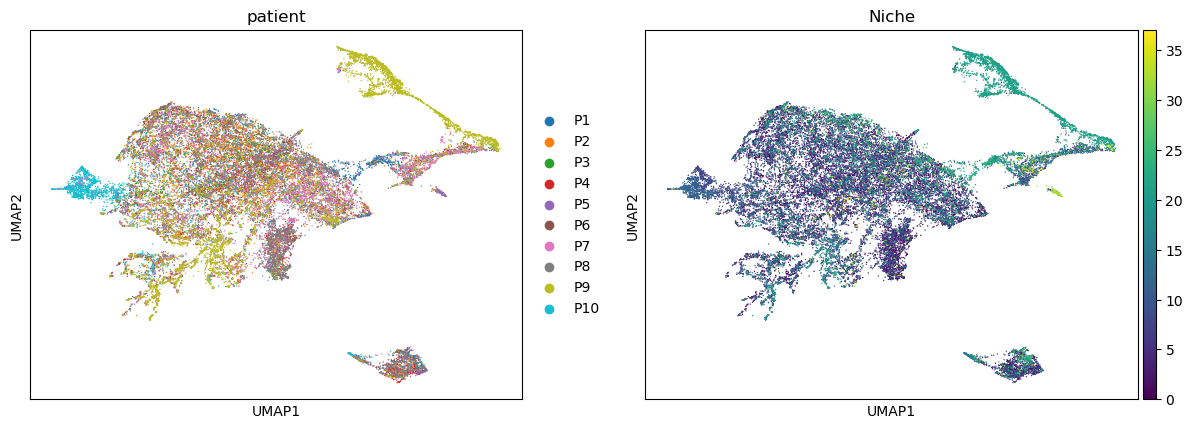

In [108]:
adata_cell = run_celltype_umap(
    adata,
    cell_column="Phenotype_big",
    cell_type="Macrophages",
    n_hvg=None, # highly variable genes
    target_sum=None, # façon de normaliser les données de transcripto,
    n_comps = None,# nombre de pc produits par PCA
    n_pcs=None, #utilisés dans neighbors donc avant umap donc regarder variance expliquée pour aider à choisir nombre pcs
    n_neighbors= 20,# utilisé pour umap
    color_by=["patient", "Niche"],
    random_state=42,
    save_dir_plot=save_dir_definition,
    scale=False,
    normalization = None,
    t_SNE = False,
    params_dir = params_dir,
    imc = True
)

In [36]:
plot_pca_variance(
    adata_cell,
    plot_type="both",
    title_prefix="PCA",
    save_path=save_dir_definition,
    figsize=(7,5),
    dpi=300,
    show_plot = True,
    
)

ValueError: PCA non trouvée. Lance sc.tl.pca() avant.

In [ ]:
#save_dir_definition = None

leiden     0     1    2    3
Niche                       
0       4996    14  567   58
1       1739     9  112   15
2       2342    12   94    4
3        726   139   45    8
4       1148     1   89   94
5        409    58    9   11
6       1911    11  190   26
7       1797    21   45    4
8        818    98   80    2
9        713   523   26    1
10       368   199   79    0
11        74     5   12    7
12       707     2    3    1
13      1513     9   24  196
14      1098     9   22    1
15       815     7  259   15
16        36   160    6    0
17       788     6   28    0
18        80    37    4    1
19       273    43   21    2
20       168   309   45    0
21        93  2375    1    0
22        52    47   29    0
23       263     7    3   41
24       523    39   91    0
25        79     9   11    1
26        35     1    0    0
27       217    21    9    0
28        42    22    1    0
29        71    13    0    0
30        27    10   15    0
31        86     0    2    0
32        21  

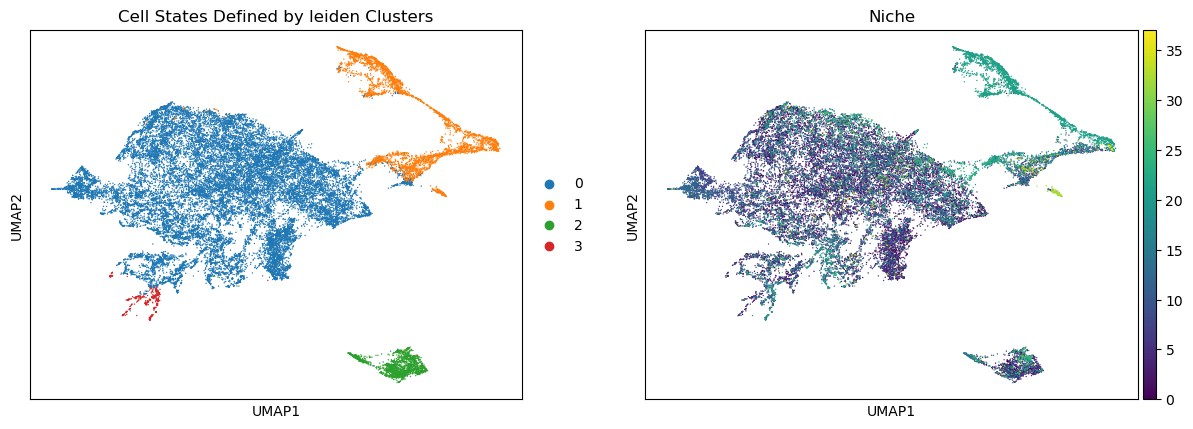

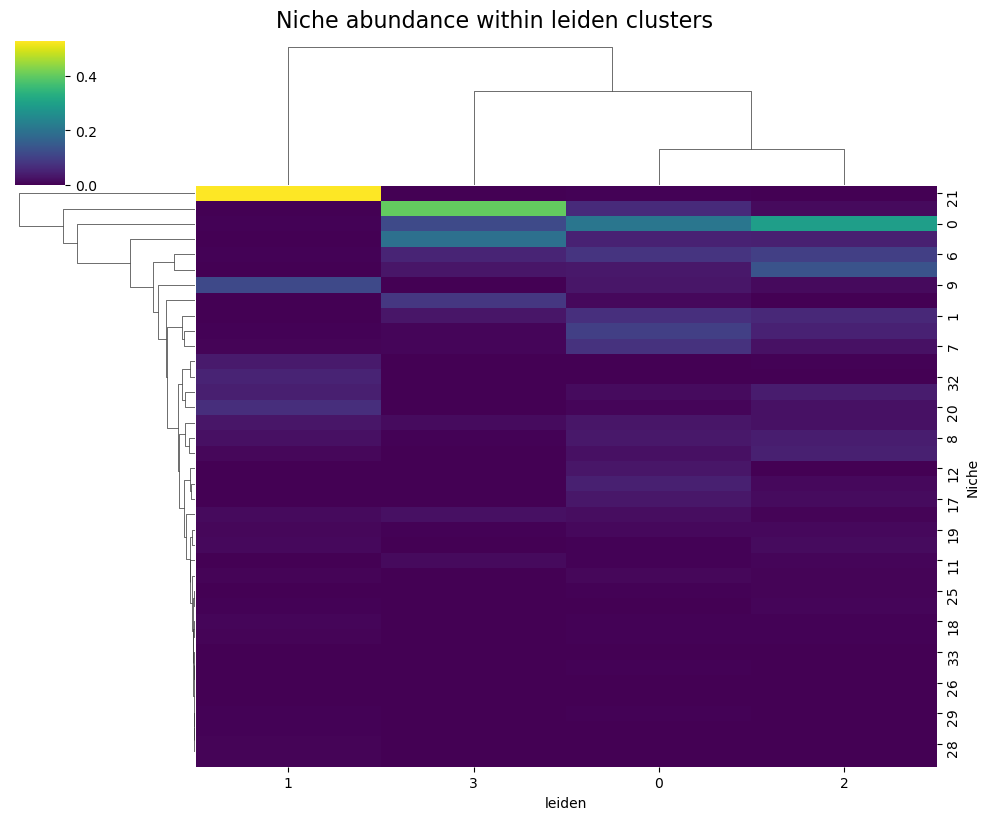

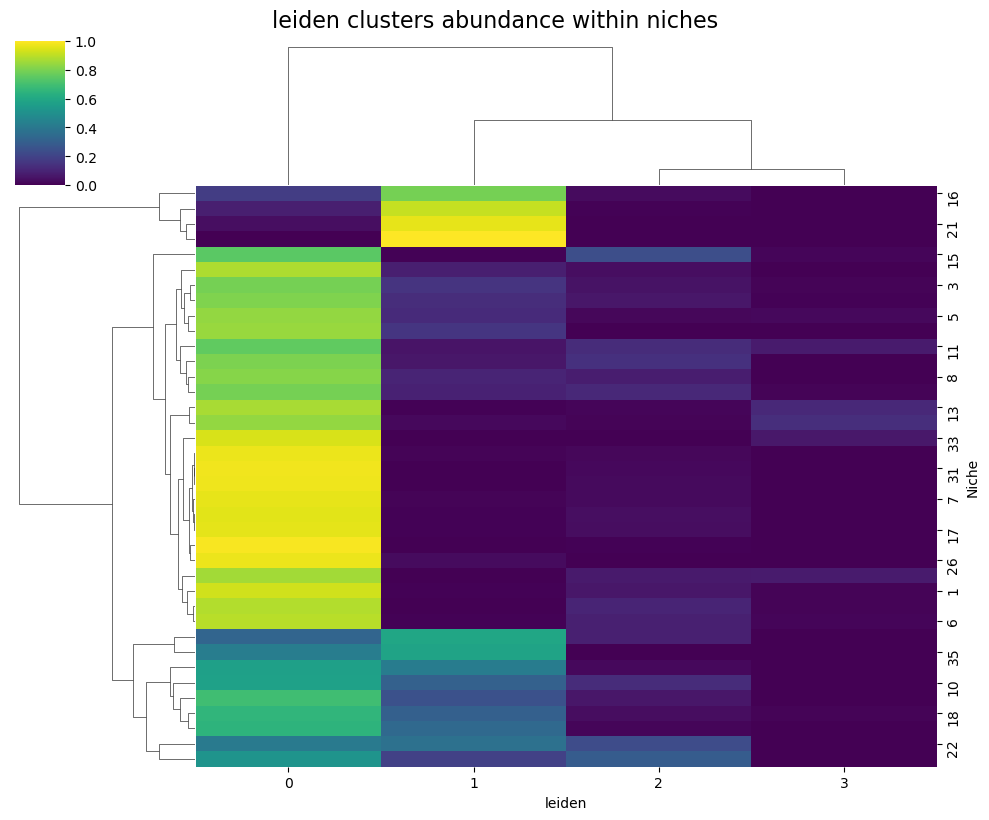

In [116]:
adata_cell, tab, _, _ = leiden_niche_analysis(
    adata_cell,
    niche_key="Niche",
    cluster_key="leiden",
    resolution=0.085,
    random_state=42,
    cmap="viridis",
    figsize=(10,8),
    save_dir_plot=save_dir_definition,
    plots_to_save=["heatmap"],
    show_plots=True,
    params_dir = params_dir
)


In [117]:

mapping_leiden = None

In [28]:
mapping_leiden = {
    0: 0,
    1: 1,
    2: 2,
    3: 3,
    4: 4,
    5: 5,
    6: 6,
    7: 1,
    8: 8,
    9: 9,
    10: 6,
    11: 9,
    12: 12,
    13: 13,
    14: 14,
    15: 4,
    16: 16,
    17: 9,
    18: 18,
    19: 19,
    20: 3,
    21: 21,
    22: 22,
    23: 23,
    24: 3,
    25: 25,
    26: 3,
    27: 22,
    28: 22,
    29: 12,
    30: 3,
    31: 23,
    32: 32,
    33: 33,
    34: 8
}

In [114]:

# mapping pour regrouper les clusters dont les niches qui les composent se ressemblent (normalisation niche sur la heatmap)
mapping_leiden = {
    0 : 0,
    1 : 1,
    2 : 2,
    3 : 2,
    4 : 3,

 

 
}



leiden_clean     0     1    2    3
Niche                             
0             4996    14  567   58
1             1739     9  112   15
2             2342    12   94    4
3              726   139   45    8
4             1148     1   89   94
5              409    58    9   11
6             1911    11  190   26
7             1797    21   45    4
8              818    98   80    2
9              713   523   26    1
10             368   199   79    0
11              74     5   12    7
12             707     2    3    1
13            1513     9   24  196
14            1098     9   22    1
15             815     7  259   15
16              36   160    6    0
17             788     6   28    0
18              80    37    4    1
19             273    43   21    2
20             168   309   45    0
21              93  2375    1    0
22              52    47   29    0
23             263     7    3   41
24             523    39   91    0
25              79     9   11    1
26              35  

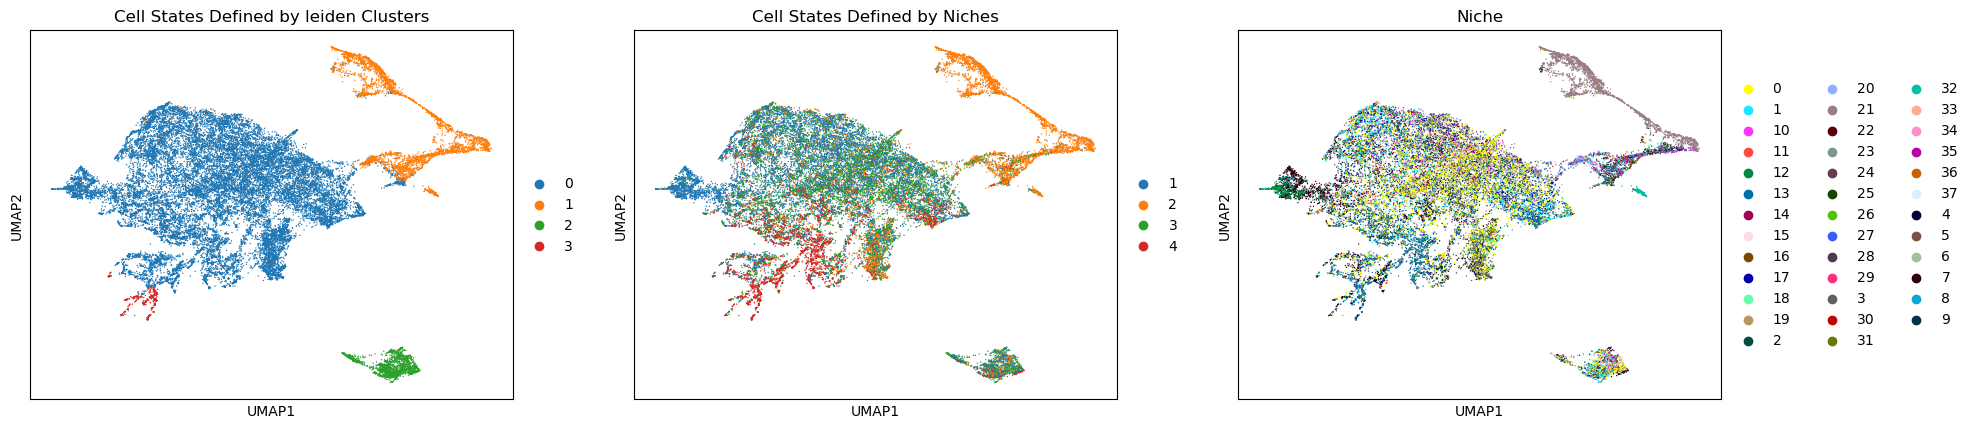

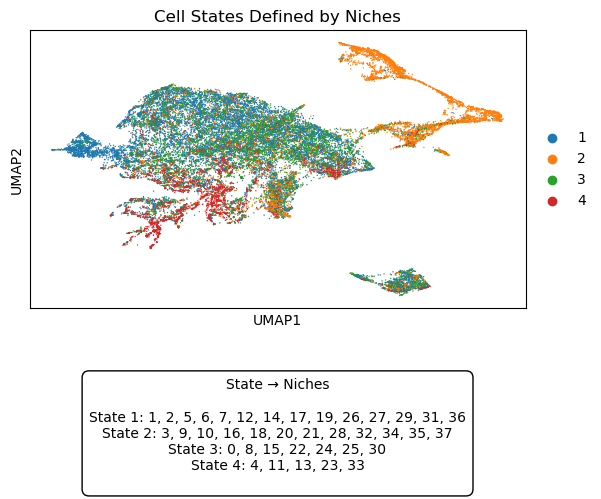

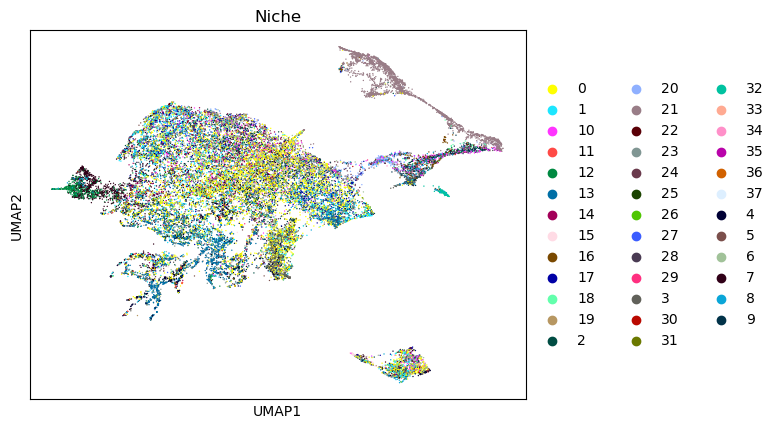

In [124]:
adata_cell_final = adata_cell.copy()

import seaborn as sns

palette3 = plt.cm.tab10.colors[:10]
palette2 = sns.color_palette("hls",5)
palette1 = sns.color_palette("bright",10)
palette = list(palette1) + list(palette2) + list(palette3)

adata_cell_final, clean_tab, state_mapping = assign_niche_states(
    adata_cell_final,
    niche_key="Niche",
    leiden_key="leiden",
    clean_leiden_key="leiden_clean",
    state_key="state",
    mapping_leiden=mapping_leiden,
    state_mapping=None,
    compute_state_mapping=True,
    palette_state= None ,
    save_dir_plot=save_dir_definition,
    plot_close = False
)



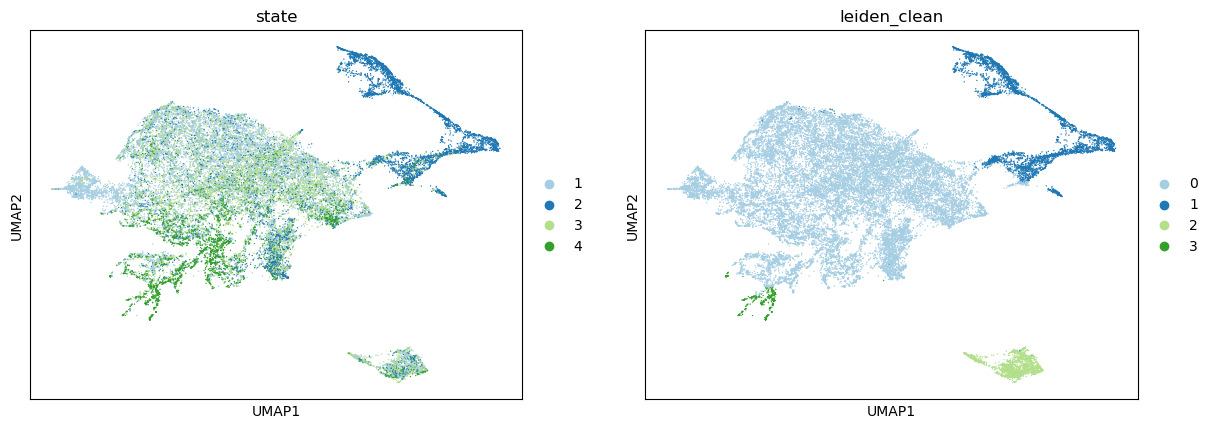

In [119]:
umap = adata_cell_final.copy()
import seaborn as sns
palette4 = sns.color_palette("deep", 10)
palette3 = sns.color_palette("hls", 10)
palette1 = sns.color_palette("Paired", 12)
palette2 = sns.color_palette("dark", 10)
palette5 = sns.color_palette("BrBG", 10)



palette = list(palette1) + list(palette2) + list(palette3) + list(palette4) + list(palette5) 

palette.pop(16)

palette.pop(45)
palette.pop(45)

sc.pl.umap(
        umap,
        color=[
           
            
            "state",
            "leiden_clean"
        ],
        palette =palette

    )

In [120]:
umap

AnnData object with n_obs × n_vars = 31080 × 27
    obs: 'Object', 'Phenotype', 'area', 'centroid-0', 'centroid-1', 'axis_major_length', 'axis_minor_length', 'eccentricity', 'source_file', 'cell_id', 'Niche', 'Macro_label', 'double_status', 'patient_sample', 'patient', 'sample', 'Phenotype_big', 'pre_processed', 'leiden', 'leiden_clean', 'state'
    uns: 'neighbors', 'umap', 'patient_colors', 'analysis_params', 'leiden', 'leiden_params', 'leiden_colors', 'Niche_colors', 'state_colors', 'leiden_clean_colors'
    obsm: 'spatial', 'X_umap'
    obsp: 'distances', 'connectivities'

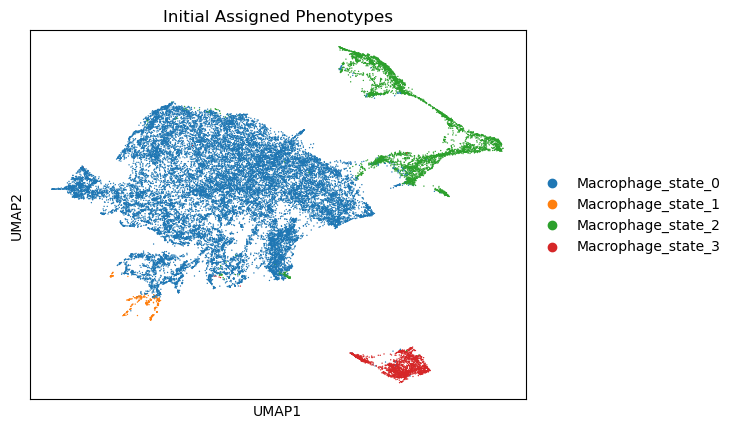

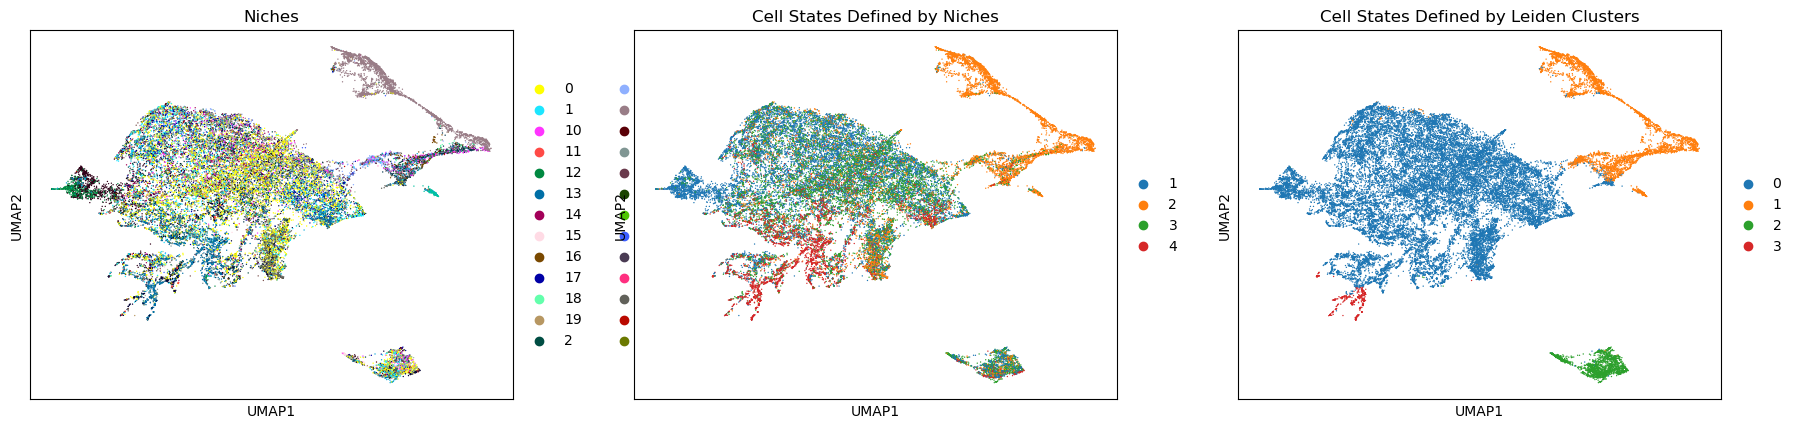

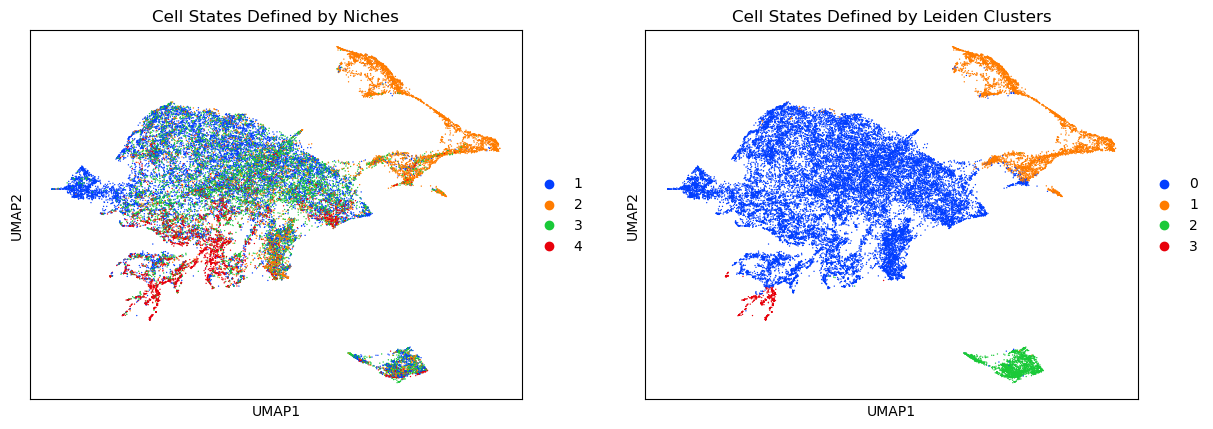

In [121]:
umap = adata_cell_final.copy()
import seaborn as sns
palette3 = plt.cm.tab10.colors[:10]
palette2 = sns.color_palette("hls",5)
palette1 = sns.color_palette("bright",10)
palette = list(palette1) + list(palette2) + list(palette3)

umap = adata_cell_final.copy()

sc.pl.umap(
        umap,
        color=[
           
            "Phenotype",

            
        ],
        title = "Initial Assigned Phenotypes",
        show = False,

    )
plt.savefig(
    save_dir_definition / "umap_initial_assigned_phenotypes.png",
    dpi=300,
    bbox_inches="tight",
)


sc.pl.umap(
        umap,
        color=[
            "Niche",
            
            "state",
            "leiden"
        ],
        title = ["Niches", f'Cell States Defined by Niches','Cell States Defined by Leiden Clusters'],

    )

sc.pl.umap(
        umap,
        color=[
           
            
            "state",
            "leiden_clean"
        ],
        title = [f'Cell States Defined by Niches','Cell States Defined by Leiden Clusters'],
        palette =palette

    )

In [127]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score



ari_adata = adata_cell_final.copy()

import pickle

dir = Path("OUTPUT_arcsinh/cell_states/20/states_def/macrophages4/definition")

with open(dir / "state_to_niche_mapping_dict.pkl", "rb") as f:
    state_mapping_ari = pickle.load(f)

ari_adata.obs["state_old"] = ari_adata.obs["Niche"].astype(int).map(state_mapping_ari)

leiden_clean = pd.read_csv(dir/ "cell_leiden_clean_to_cell_id_mapping.csv")
ari_adata.obs["leiden_clean_old"] = (
    leiden_clean.set_index("cell_id")
    .loc[ari_adata.obs_names, "leiden_clean"]
    .values
)


ari = adjusted_rand_score(
    ari_adata.obs["state"],
    ari_adata.obs["state_old"]
)

nmi = normalized_mutual_info_score(
    ari_adata.obs["state"],
    ari_adata.obs["state_old"]
)

print(ari, nmi)

ValueError: Input contains NaN.

In [126]:
adata_cell_final.obs["double_status"] = (
    adata_cell_final.obs["double_status"]
    .astype("category")
)

adata_cell_final.write_h5ad(save_dir_definition/"adata_cell_final.h5ad")

In [128]:
#exporter state mapping dictionaire mapant niche à state
import pickle


with open(save_dir_definition/"state_to_niche_mapping_dict.pkl", "wb") as f:
    pickle.dump(state_mapping, f)

    

In [129]:
#exporter data frame avec correspondance cell id avec state
import pandas as pd


cell_state = pd.DataFrame({
    "cell_id": adata_cell_final.obs_names,
    "state": adata_cell_final.obs["state"]
})

cell_state.to_csv(
    save_dir_definition/"cell_state_to_cell_id_mapping.csv",
    index=False
)

In [130]:
#exporter data frame avec correspondance cell id avec leiden_clean
import pandas as pd


cell_state = pd.DataFrame({
    "cell_id": adata_cell_final.obs_names,
    "leiden_clean": adata_cell_final.obs["leiden_clean"]
})

cell_state.to_csv(
    save_dir_definition/"cell_leiden_clean_to_cell_id_mapping.csv",
    index=False
)

In [131]:
adata

AnnData object with n_obs × n_vars = 543087 × 27
    obs: 'Object', 'Phenotype', 'area', 'centroid-0', 'centroid-1', 'axis_major_length', 'axis_minor_length', 'eccentricity', 'source_file', 'cell_id', 'Niche', 'Macro_label', 'double_status', 'patient_sample', 'patient', 'sample', 'Phenotype_big', 'pre_processed'
    obsm: 'spatial'

### Abundance plot

In [132]:

phenotype_mapping = {
    "Macrophages" : "macrophages",
    
    }

save_dir_definition = Path("./OUTPUT_arcsinh/cell_states/20/states_def/macrophages5/definition")
adata_cell_gsea = (
    adata[
        adata.obs['Phenotype_big'] == 'Macrophages'
    ]
    .copy()
)

#load le state_mapping

import pickle


with open(save_dir_definition / "state_to_niche_mapping_dict.pkl", "rb") as f:
    state_mapping = pickle.load(f)

adata_cell_gsea.obs["state"] = adata_cell_gsea.obs["Niche"].map(state_mapping)


adata_cell_final = adata_cell_gsea



In [240]:
adata_cell_final

AnnData object with n_obs × n_vars = 31080 × 27
    obs: 'Object', 'Phenotype', 'area', 'centroid-0', 'centroid-1', 'axis_major_length', 'axis_minor_length', 'eccentricity', 'source_file', 'cell_id', 'Niche', 'patient_sample', 'patient', 'sample', 'Phenotype_big', 'pre_processed', 'state'
    var: 'std'
    obsm: 'spatial'

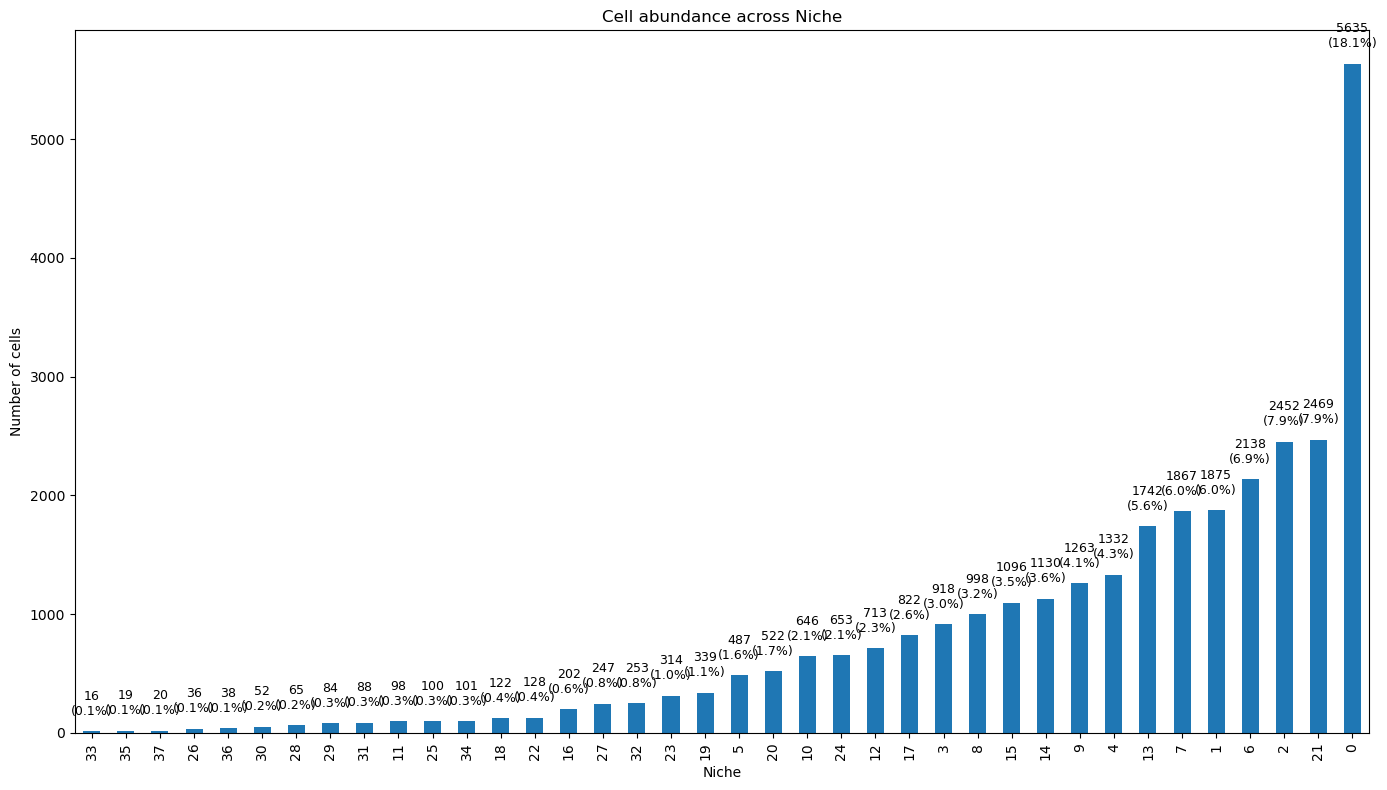

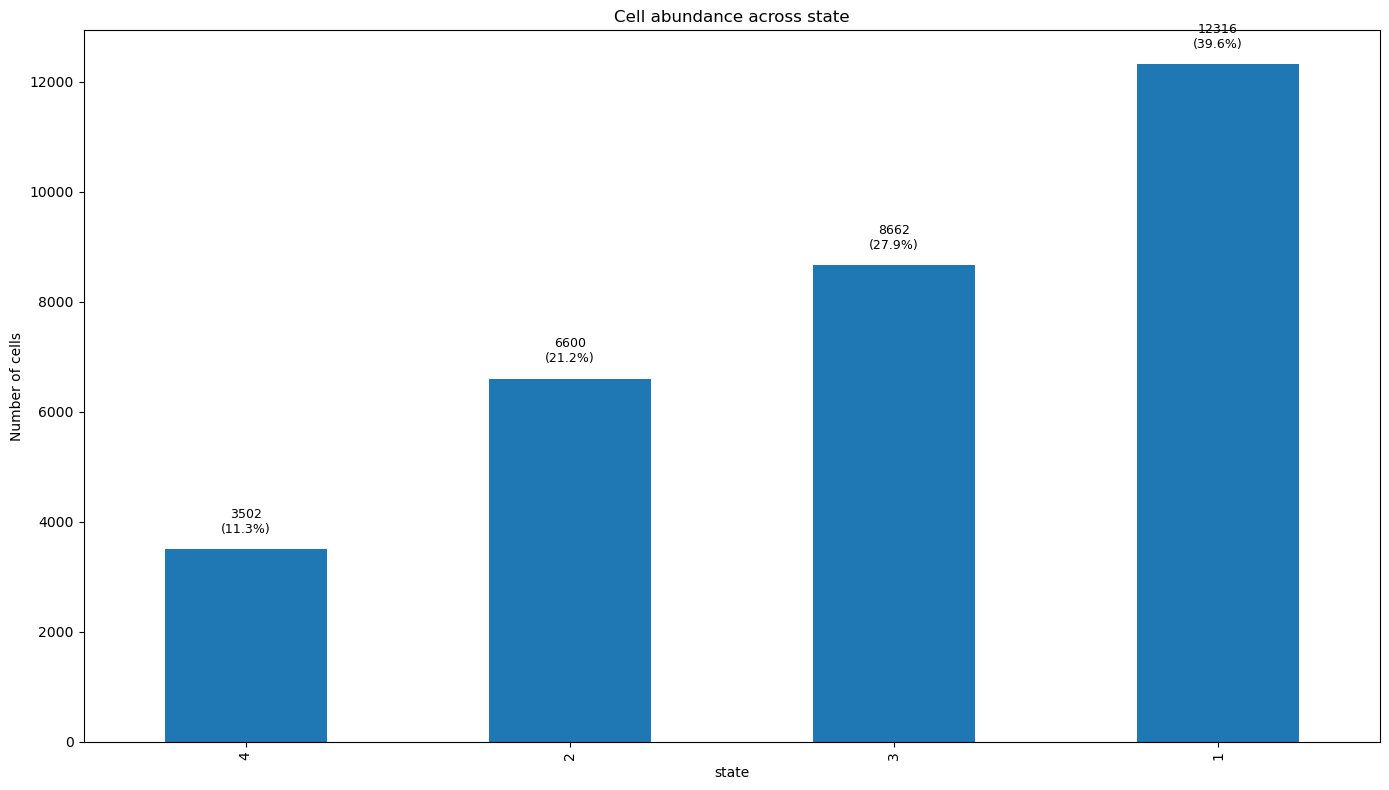

{'niche': {'counts': Niche
  33      16
  35      19
  37      20
  26      36
  36      38
  30      52
  28      65
  29      84
  31      88
  11      98
  25     100
  34     101
  18     122
  22     128
  16     202
  27     247
  32     253
  23     314
  19     339
  5      487
  20     522
  10     646
  24     653
  12     713
  17     822
  3      918
  8      998
  15    1096
  14    1130
  9     1263
  4     1332
  13    1742
  7     1867
  1     1875
  6     2138
  2     2452
  21    2469
  0     5635
  Name: count, dtype: int64,
  'percent': Niche
  33     0.051480
  35     0.061133
  37     0.064350
  26     0.115830
  36     0.122265
  30     0.167310
  28     0.209138
  29     0.270270
  31     0.283140
  11     0.315315
  25     0.321750
  34     0.324968
  18     0.392535
  22     0.411840
  16     0.649936
  27     0.794723
  32     0.814028
  23     1.010296
  19     1.090734
  5      1.566924
  20     1.679537
  10     2.078507
  24     2.101030
  12     2.294080

In [ ]:
plot_niche_state_abundance(
    adata_cell_final,
    niche_key="Niche",
    state_key="state",
    figsize=(14, 8),
    save_dir_plot=save_dir_definition,
    show=True,
)

In [107]:
from pathlib import Path
import pickle

phenotype_mapping = {
    "Macrophages": "macrophages",
    "B Cells": "b_cells",
    "Cytotoxic T Cells": "cytotoxic_T_cells",
    "Regulatory T Cells": "regulatory_T_cells",
    "Plasma Cells": "plasma_cells",
    "Differentiating Tumor Cells": "differentiating_tumor_cells",
    "Mast Cells": "mast_cells",
    "Dendritic Cells": "dendritic_cells",
    "Neutrophils": "neutrophils"
}


for phenotype, phenotype_folder in phenotype_mapping.items():

    print(f"Processing {phenotype}...")

    # Sélection des cellules du phenotype
    adata_cell_gsea = (
        adata[
            adata.obs["group"] == phenotype
        ]
        .copy()
    )

    # Dossier définition
    save_dir_definition = Path(
        f"./OUTPUT/states/states_def/{phenotype_folder}/definition"
    )

    mapping_file = save_dir_definition / "state_to_niche_mapping_dict.pkl"

    if not mapping_file.exists():
        print(f"Mapping absent pour {phenotype}, skip")
        continue

    # Charger state mapping
    with open(mapping_file, "rb") as f:
        state_mapping = pickle.load(f)

    # Ajouter les states
    adata_cell_gsea.obs["state"] = (
        adata_cell_gsea.obs["Niche"]
        .map(state_mapping)
    )

    # Optionnel : sauvegarder l'objet
    # adata_cell_final[phenotype] = adata_cell_gsea

    # Plot abundance niche + state
    plot_niche_state_abundance(
        adata_cell_gsea,
        niche_key="Niche",
        state_key="state",
        figsize=(12, 8),
        save_dir_plot=save_dir_definition,
        show=True,
    )

    print(
        f"{phenotype}: "
        f"{adata_cell_gsea.n_obs} cells | "
        f"{adata_cell_gsea.obs['state'].nunique()} states"
    )

Processing Macrophages...


KeyError: 'group'

## KRT17 positive and negative tumor cells

In [1]:
adata.obs['Phenotype'].unique()


NameError: name 'adata' is not defined

In [ ]:
cell_types = [
    'Epithelial tumour (basal)',
    'Epithelial tumour',


]

mapping = {
    'Epithelial tumour (basal)': "Tumour",
    'Epithelial tumour' : "Tumour",


}

"164Dy-KRT17" in adata.var_names



True

In [120]:


adata_cell = adata[
    adata.obs["Phenotype"].isin(cell_types)
].copy()

adata_cell.obs["Phenotype_big"] = adata.obs["Phenotype"].replace(mapping)

In [121]:
adata_cell

AnnData object with n_obs × n_vars = 106345 × 38
    obs: 'Object', 'Phenotype', 'area', 'centroid-0', 'centroid-1', 'axis_major_length', 'axis_minor_length', 'eccentricity', 'source_file', 'cell_id', 'Niche', 'patient_sample', 'patient', 'sample', 'Phenotype_big'
    obsm: 'spatial'

In [122]:
adata_cell.var_names[adata_cell.var_names.str.contains("164Dy-KRT17", case=False)]

Index(['164Dy-KRT17'], dtype='object')

/home/mohamed.tahounza/miniconda3/envs/mosna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:961: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_130672/216416575.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


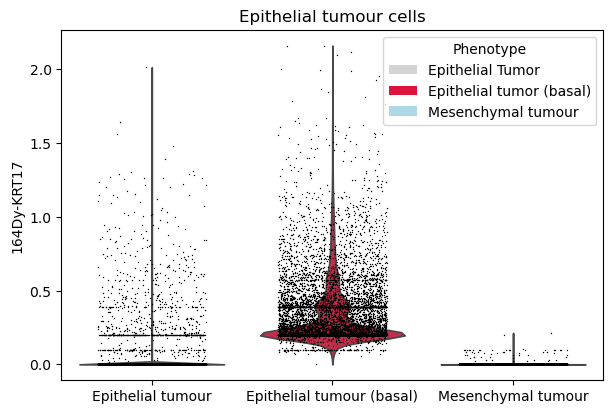

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Définir les couleurs
palette = {
    "Epithelial tumour": "lightgrey",
    "Epithelial tumour (basal)": "crimson",

}

sc.pl.violin(
    adata_cell,
    keys="164Dy-KRT17",
    groupby="Phenotype",
    stripplot=True,
    jitter=0.3,
    palette=palette,
    show=False
)

plt.ylabel("164Dy-KRT17")
plt.xlabel("")
plt.title("Epithelial tumour cells")


# Légende personnalisée avec rectangles colorés
legend_elements = [
    Patch(
        facecolor="lightgrey",
        edgecolor="none",
        label="Epithelial Tumor"
    ),
    Patch(
        facecolor="crimson",
        edgecolor="none",
        label="Epithelial tumor (basal)"
    ),


]

plt.legend(
    handles=legend_elements,
    title="Phenotype",
    frameon=True,
    fancybox=True,
    loc="upper right",
    fontsize=10,
    title_fontsize=10
)

plt.tight_layout()


plt.savefig(
    "./OUTPUT_arcsinh/cell_states/tumor_cells_KRT17_status/Violin_Tumour_epithelial.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

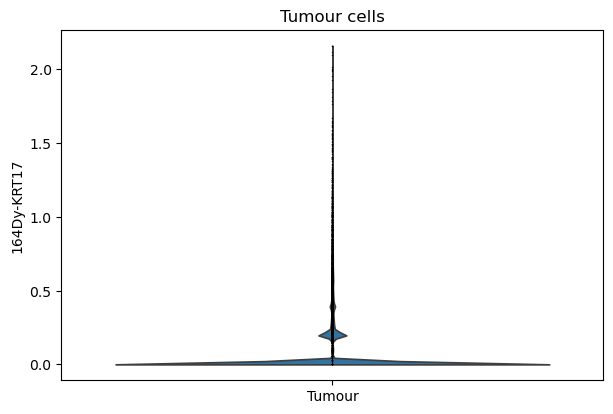

In [111]:
import scanpy as sc



sc.pl.violin(
    adata_cell,
    keys="164Dy-KRT17",
    groupby="Phenotype_big",
    jitter = False,
    show = False
   
)


plt.ylabel("164Dy-KRT17")
plt.xlabel("")
plt.title("Tumour cells")


plt.savefig(
    "OUTPUT_arcsinh/cell_states/tumor_cells_KRT17_status/Violin_KRT17_Tumour.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [66]:
adata_cell.obs["Phenotype_big"]

cell_id
P10_S1_28      Tumour
P10_S1_40      Tumour
P10_S1_48      Tumour
P10_S1_66      Tumour
P10_S1_75      Tumour
                ...  
P9_S5_15065    Tumour
P9_S5_15067    Tumour
P9_S5_15068    Tumour
P9_S5_15071    Tumour
P9_S5_15078    Tumour
Name: Phenotype_big, Length: 85692, dtype: category
Categories (1, object): ['Tumour']

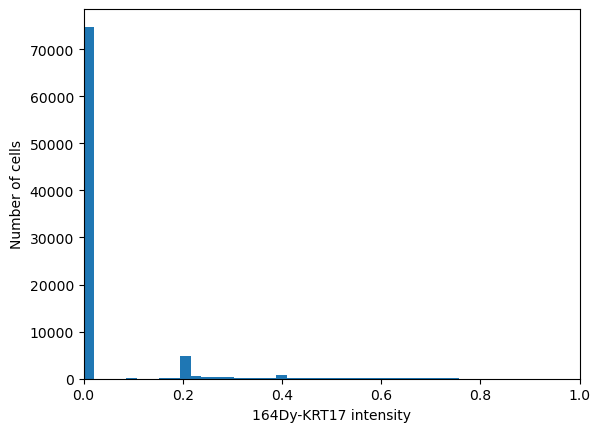

In [109]:
import numpy as np
import matplotlib.pyplot as plt

krt17 = np.array(adata_cell[adata_cell.obs["Phenotype_big"]=="Tumour", "164Dy-KRT17"].X).flatten()

plt.hist(krt17, bins=100)
plt.xlim(0, 1)
plt.xlabel("164Dy-KRT17 intensity")
plt.ylabel("Number of cells")


plt.savefig(
    "OUTPUT_arcsinh/cell_states/tumor_cells_KRT17_status/barplot_KRT17_intensity_Tumour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

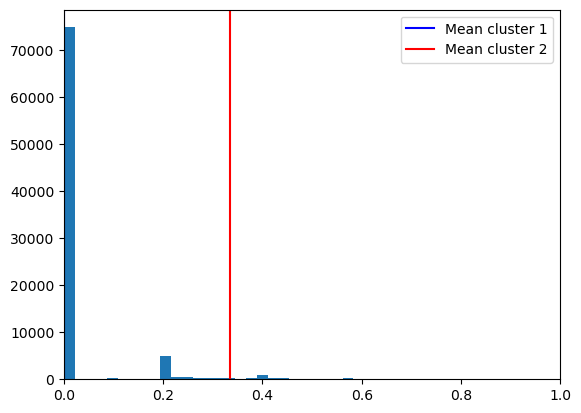

In [75]:
import matplotlib.pyplot as plt

plt.hist(krt17, bins=100)
plt.axvline(gmm.means_[0][0], color="blue", label="Mean cluster 1")
plt.axvline(gmm.means_[1][0], color="red", label="Mean cluster 2")
plt.xlim(0,1)
plt.legend()
plt.show()

Moyennes des deux populations :
[4.19456834e-08 3.33554384e-01]

Nombre de cellules :
KRT17_status
KRT17-    74772
KRT17+    10920
Name: count, dtype: int64


/tmp/ipykernel_11461/3060545486.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


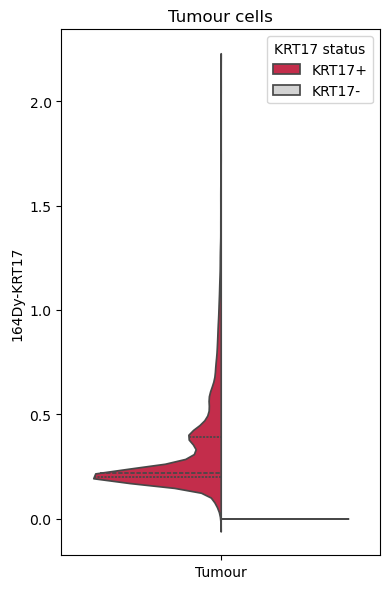

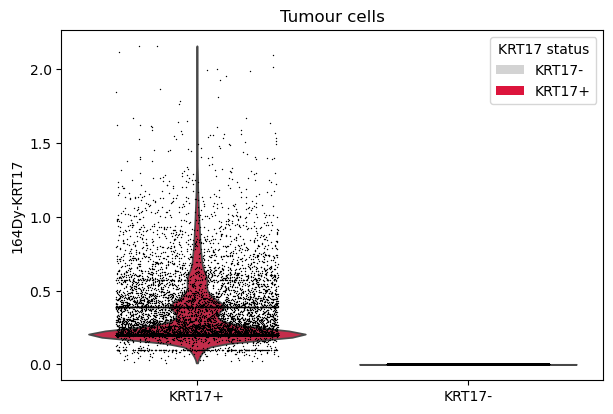

Moyennes GMM :
   GMM_cluster    KRT17_mean
0            0  4.194568e-08
1            1  3.335544e-01

Nombre de cellules par statut :
  KRT17_status  n_cells
0       KRT17-    74772
1       KRT17+    10920

Statistiques KRT17 par statut :
                count          mean       std     min        1%       5%  \
KRT17_status                                                               
KRT17+        10920.0  3.340624e-01  0.229422  0.0098  0.099834  0.19869   
KRT17-        74772.0  4.413409e-08  0.000012  0.0000  0.000000  0.00000   

                  10%      25%       50%       75%       90%       95%  \
KRT17_status                                                             
KRT17+        0.19869  0.19869  0.219532  0.390685  0.611887  0.808135   
KRT17-        0.00000  0.00000  0.000000  0.000000  0.000000  0.000000   

                   99%       max  
KRT17_status                      
KRT17+        1.234223  2.159315  
KRT17-        0.000000  0.003300  

Exports sauvegard

/tmp/ipykernel_11461/3060545486.py:217: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("KRT17_status")["KRT17_expr"]


In [113]:
import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# ==========================
# 1. Sélection des cellules tumorales
# ==========================

tumor = adata_cell[adata_cell.obs["Phenotype_big"] == "Tumour"].copy()

# ==========================
# 2. Extraction de l'expression KRT17
# ==========================

tumor.obs["KRT17_expr"] = np.asarray(
    tumor[:, "164Dy-KRT17"].X
).flatten()

# ==========================
# 3. Classification KRT17+ / KRT17-
# ==========================

gmm = GaussianMixture(n_components=2, random_state=0)
gmm.fit(tumor.obs[["KRT17_expr"]])

clusters = gmm.predict(tumor.obs[["KRT17_expr"]])
positive_cluster = np.argmax(gmm.means_.flatten())

tumor.obs["KRT17_status"] = np.where(
    clusters == positive_cluster,
    "KRT17+",
    "KRT17-"
)

print("Moyennes des deux populations :")
print(gmm.means_.flatten())

print("\nNombre de cellules :")
print(tumor.obs["KRT17_status"].value_counts())

# ==========================
# 4. Export des données
# ==========================

cols = [
    "cell_id",
    "Phenotype",
    "Phenotype_big",
    "KRT17_expr",
    "KRT17_status"
]

tumor.obs[cols].to_csv(
    "OUTPUT_arcsinh/cell_states/tumor_cells_KRT17_status/Tumour_KRT17_status.csv",
    index=True
)

# ==========================
# 5. Violin plot
# ==========================

plt.figure(figsize=(4,6))

sns.violinplot(
    data=tumor.obs,
    x=np.repeat("Tumour", tumor.n_obs),
    y="KRT17_expr",
    hue="KRT17_status",
    split=True,
    inner="quart",
    density_norm="width",
    palette={
        "KRT17-":"lightgrey",
        "KRT17+":"crimson"
    }
)

plt.ylabel("164Dy-KRT17")
plt.xlabel("")
plt.title("Tumour cells")
plt.legend(title="KRT17 status")

plt.tight_layout()

# ==========================
# 6. Export du plot
# ==========================

plt.savefig(
    "OUTPUT_arcsinh/cell_states/tumor_cells_KRT17_status/Violin_KRT17_Tumour_status.png",
    dpi=300,
    bbox_inches="tight"
)


fig = plt.gcf()

sc.pl.violin(
    tumor,
    keys="164Dy-KRT17",
    groupby="KRT17_status",
    hue="KRT17_status",
    stripplot=True,
    jitter=0.3,
    palette={
        "KRT17-":"lightgrey",
        "KRT17+":"crimson"
    },
    show=False
)

plt.ylabel("164Dy-KRT17")
plt.xlabel("")
plt.title("Tumour cells")

handles, labels = plt.gca().get_legend_handles_labels()

from matplotlib.patches import Patch

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="lightgrey", edgecolor="none", label="KRT17-"),
    Patch(facecolor="crimson", edgecolor="none", label="KRT17+")
]

plt.legend(
    handles=legend_elements,
    title="KRT17 status",
    frameon=True,
    loc="upper right",
    fontsize=10,
    title_fontsize=10
)
plt.tight_layout()

plt.savefig(
    "OUTPUT_arcsinh/cell_states/tumor_cells_KRT17_status/double_Violin_KRT17_Tumour.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

import os
import pandas as pd

# ==========================
# 4. Export des données et statistiques
# ==========================

output_dir = "OUTPUT_arcsinh/cell_states/tumor_cells_KRT17_status/"

# Création du dossier si nécessaire
os.makedirs(output_dir, exist_ok=True)


# --------------------------
# Export des cellules avec leur statut
# --------------------------

cols = [
    "Phenotype",
    "Phenotype_big",
    "KRT17_expr",
    "KRT17_status"
]

tumor.obs[cols].to_csv(
    output_dir + "Tumour_KRT17_status.csv",
    index=True
)


# --------------------------
# Export des moyennes GMM
# --------------------------

gmm_summary = pd.DataFrame({
    "GMM_cluster": np.arange(len(gmm.means_.flatten())),
    "KRT17_mean": gmm.means_.flatten()
})

gmm_summary.to_csv(
    output_dir + "Tumour_KRT17_GMM_means.csv",
    index=False
)


# --------------------------
# Export du nombre de cellules
# par statut KRT17
# --------------------------

cell_counts = (
    tumor.obs["KRT17_status"]
    .value_counts()
    .rename_axis("KRT17_status")
    .reset_index(name="n_cells")
)

cell_counts.to_csv(
    output_dir + "Tumour_KRT17_cell_counts.csv",
    index=False
)


# --------------------------
# Statistiques descriptives
# de KRT17 selon le statut
# avec percentiles
# --------------------------

KRT17_describe = (
    tumor.obs
    .groupby("KRT17_status")["KRT17_expr"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

KRT17_describe.to_csv(
    output_dir + "Tumour_KRT17_describe_by_status.csv"
)


# --------------------------
# Affichage résumé
# --------------------------

print("Moyennes GMM :")
print(gmm_summary)

print("\nNombre de cellules par statut :")
print(cell_counts)

print("\nStatistiques KRT17 par statut :")
print(KRT17_describe)

print("\nExports sauvegardés dans :")
print(output_dir)


## S100A2 positive and negative tumor cells

In [18]:
cell_types = [
    'Epithelial tumour (basal)',
    'Epithelial tumour'

]

mapping = {
    'Epithelial tumour (basal)': "Tumour",
    'Epithelial tumour' : "Tumour"

}

"172Yb-S100A2" in adata.var_names



True

In [19]:
adata_cell = adata[
    adata.obs["Phenotype"].isin(cell_types)
].copy()

adata_cell.obs["Phenotype_big"] = adata.obs["Phenotype"].replace(mapping)

adata_cell.var_names[adata_cell.var_names.str.contains("172Yb-S100A2", case=False)]

Index(['172Yb-S100A2'], dtype='object')

/home/mohamed.tahounza/miniconda3/envs/mosna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:961: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_130672/2098793756.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


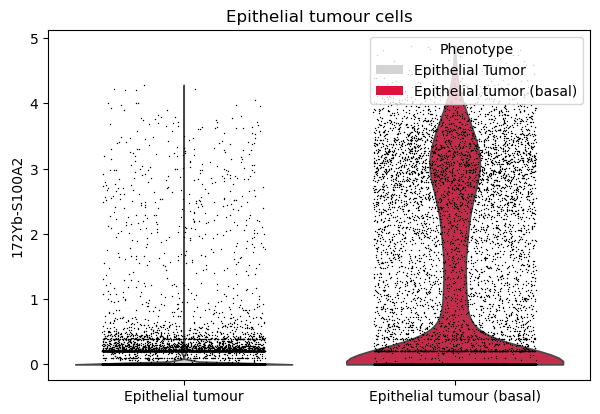

In [21]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Définir les couleurs
palette = {
    "Epithelial tumour": "lightgrey",
    "Epithelial tumour (basal)": "crimson"
}

sc.pl.violin(
    adata_cell,
    keys="172Yb-S100A2",
    groupby="Phenotype",
    stripplot=True,
    jitter=0.3,
    palette=palette,
    show=False
)

plt.ylabel("172Yb-S100A2")
plt.xlabel("")
plt.title("Epithelial tumour cells")


# Légende personnalisée avec rectangles colorés
legend_elements = [
    Patch(
        facecolor="lightgrey",
        edgecolor="none",
        label="Epithelial Tumor"
    ),
    Patch(
        facecolor="crimson",
        edgecolor="none",
        label="Epithelial tumor (basal)"
    )
]

plt.legend(
    handles=legend_elements,
    title="Phenotype",
    frameon=True,
    fancybox=True,
    loc="upper right",
    fontsize=10,
    title_fontsize=10
)

plt.tight_layout()

plt.savefig(
    "./OUTPUT_arcsinh/cell_states/tumor_cells_S100A2_status/Violin_Tumour_epithelial.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

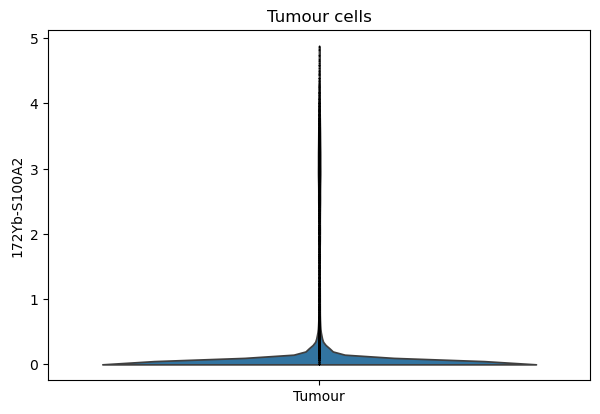

In [22]:
import scanpy as sc



sc.pl.violin(
    adata_cell,
    keys="172Yb-S100A2",
    groupby="Phenotype_big",
    jitter = False,
    show = False
   
)


plt.ylabel("172Yb-S100A2")
plt.xlabel("")
plt.title("Tumour cells")


plt.savefig(
    "OUTPUT_arcsinh/cell_states/tumor_cells_S100A2_status/Violin_KRT17_Tumour.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

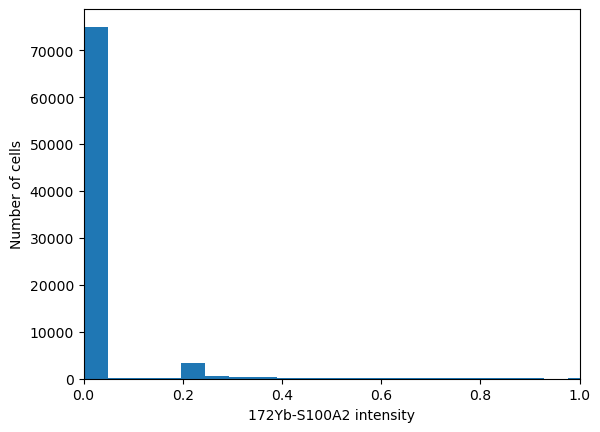

In [23]:
import numpy as np
import matplotlib.pyplot as plt

krt17 = np.array(adata_cell[adata_cell.obs["Phenotype_big"]=="Tumour", "172Yb-S100A2"].X).flatten()

plt.hist(krt17, bins=100)
plt.xlim(0, 1)
plt.xlabel("172Yb-S100A2 intensity")
plt.ylabel("Number of cells")


plt.savefig(
    "OUTPUT_arcsinh/cell_states/tumor_cells_KRT17_status/barplot_S100A2_intensity_Tumour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

Moyennes des deux populations :
[1.26127338e-13 1.32962493e+00]

Nombre de cellules :
S100A2_status
S100A2-    74991
S100A2+    10701
Name: count, dtype: int64


/tmp/ipykernel_130672/3150252374.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


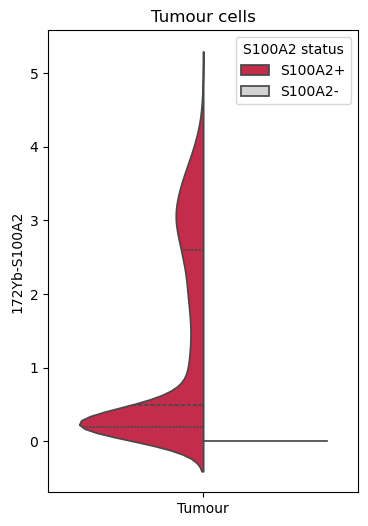

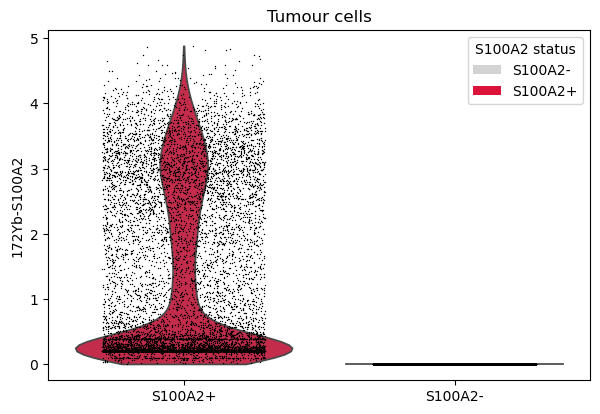

Moyennes GMM :
   GMM_cluster   S100A2_mean
0            0  1.261273e-13
1            1  1.329625e+00

Nombre de cellules par statut :
  S100A2_status  n_cells
0       S100A2-    74991
1       S100A2+    10701

Statistiques S100A2 par statut :
                 count      mean       std     min        1%       5%  \
S100A2_status                                                           
S100A2+        10701.0  1.330232  1.316219  0.0068  0.099834  0.19869   
S100A2-        74991.0  0.000000  0.000000  0.0000  0.000000  0.00000   

                   10%      25%       50%       75%       90%       95%  \
S100A2_status                                                             
S100A2+        0.19869  0.19869  0.501157  2.597377  3.364001  3.677881   
S100A2-        0.00000  0.00000  0.000000  0.000000  0.000000  0.000000   

                    99%       max  
S100A2_status                      
S100A2+        4.161215  4.883296  
S100A2-        0.000000  0.000000  

Exports sauvegard

/tmp/ipykernel_130672/3150252374.py:217: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("S100A2_status")["S100A2_expr"]


In [28]:
import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# ==========================
# 1. Sélection des cellules tumorales
# ==========================

tumor = adata_cell[adata_cell.obs["Phenotype_big"] == "Tumour"].copy()

# ==========================
# 2. Extraction de l'expression S100A2
# ==========================

tumor.obs["S100A2_expr"] = np.asarray(
    tumor[:, "172Yb-S100A2"].X
).flatten()

# ==========================
# 3. Classification + / -
# ==========================

gmm = GaussianMixture(n_components=2, random_state=0)
gmm.fit(tumor.obs[["S100A2_expr"]])

clusters = gmm.predict(tumor.obs[["S100A2_expr"]])
positive_cluster = np.argmax(gmm.means_.flatten())

tumor.obs["S100A2_status"] = np.where(
    clusters == positive_cluster,
    "S100A2+",
    "S100A2-"
)

print("Moyennes des deux populations :")
print(gmm.means_.flatten())

print("\nNombre de cellules :")
print(tumor.obs["S100A2_status"].value_counts())

# ==========================
# 4. Export des données
# ==========================

cols = [
    "cell_id",
    "Phenotype",
    "Phenotype_big",
    "S100A2_expr",
    "S100A2_status"
]

tumor.obs[cols].to_csv(
    "OUTPUT_arcsinh/cell_states/tumor_cells_S100A2_status/Tumour_S100A2_status.csv",
    index=True
)

# ==========================
# 5. Violin plot
# ==========================

plt.figure(figsize=(4,6))

sns.violinplot(
    data=tumor.obs,
    x=np.repeat("Tumour", tumor.n_obs),
    y="S100A2_expr",
    hue="S100A2_status",
    split=True,
    inner="quart",
    density_norm="width",
    palette={
        "S100A2-":"lightgrey",
        "S100A2+":"crimson"
    }
)

plt.ylabel("172Yb-S100A2")
plt.xlabel("")
plt.title("Tumour cells")
plt.legend(title="S100A2 status")



# ==========================
# 6. Export du plot
# ==========================

plt.savefig(
    "OUTPUT_arcsinh/cell_states/tumor_cells_S100A2_status/Violin_S100A2_Tumour_status.png",
    dpi=300,
    bbox_inches="tight"
)


fig = plt.gcf()

sc.pl.violin(
    tumor,
    keys="172Yb-S100A2",
    groupby="S100A2_status",
    hue="S100A2_status",
    stripplot=True,
    jitter=0.3,
    palette={
        "S100A2-":"lightgrey",
        "S100A2+":"crimson"
    },
    show=False
)

plt.ylabel("172Yb-S100A2")
plt.xlabel("")
plt.title("Tumour cells")

handles, labels = plt.gca().get_legend_handles_labels()

from matplotlib.patches import Patch

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="lightgrey", edgecolor="none", label="S100A2-"),
    Patch(facecolor="crimson", edgecolor="none", label="S100A2+")
]

plt.legend(
    handles=legend_elements,
    title="S100A2 status",
    frameon=True,
    loc="upper right",
    fontsize=10,
    title_fontsize=10
)
plt.tight_layout()

plt.savefig(
    "OUTPUT_arcsinh/cell_states/tumor_cells_S100A2_status/double_Violin_S100A2_Tumour.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

import os
import pandas as pd

# ==========================
# 4. Export des données et statistiques
# ==========================

output_dir = "OUTPUT_arcsinh/cell_states/tumor_cells_S100A2_status/"

# Création du dossier si nécessaire
os.makedirs(output_dir, exist_ok=True)


# --------------------------
# Export des cellules avec leur statut
# --------------------------

cols = [
    "Phenotype",
    "Phenotype_big",
    "S100A2_expr",
    "S100A2_status"
]

tumor.obs[cols].to_csv(
    output_dir + "Tumour_S100A2_status.csv",
    index=True
)


# --------------------------
# Export des moyennes GMM
# --------------------------

gmm_summary = pd.DataFrame({
    "GMM_cluster": np.arange(len(gmm.means_.flatten())),
    "S100A2_mean": gmm.means_.flatten()
})

gmm_summary.to_csv(
    output_dir + "Tumour_S100A2_GMM_means.csv",
    index=False
)


# --------------------------
# Export du nombre de cellules
# par statut S100A2
# --------------------------

cell_counts = (
    tumor.obs["S100A2_status"]
    .value_counts()
    .rename_axis("S100A2_status")
    .reset_index(name="n_cells")
)

cell_counts.to_csv(
    output_dir + "Tumour_S100A2_cell_counts.csv",
    index=False
)


# --------------------------
# Statistiques descriptives
# de S100A2 selon le statut
# avec percentiles
# --------------------------

S100A2_describe = (
    tumor.obs
    .groupby("S100A2_status")["S100A2_expr"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

S100A2_describe.to_csv(
    output_dir + "Tumour_S100A2_describe_by_status.csv"
)


# --------------------------
# Affichage résumé
# --------------------------

print("Moyennes GMM :")
print(gmm_summary)

print("\nNombre de cellules par statut :")
print(cell_counts)

print("\nStatistiques S100A2 par statut :")
print(S100A2_describe)

print("\nExports sauvegardés dans :")
print(output_dir)


## Comparaison composition en KRT17+ ou - et S1000A2 + ou - dans tumor cells

In [17]:
adata_comp = adata.copy()

cell_types = [
    'Epithelial tumour (basal)',
    'Epithelial tumour'

]

mapping = {
    'Epithelial tumour (basal)': "Tumour",
    'Epithelial tumour' : "Tumour"

}

adata_comp = adata_comp[
    adata_comp.obs["Phenotype"].isin(cell_types)
].copy()

adata_comp.obs["Phenotype_big"] = adata_comp.obs["Phenotype"].replace(mapping)

In [18]:
krt17 = pd.read_csv("OUTPUT_arcsinh/cell_states/tumor_cells_KRT17_status/Tumour_KRT17_status.csv")
s100a2 = pd.read_csv("OUTPUT_arcsinh/cell_states/tumor_cells_S100A2_status/Tumour_S100A2_status.csv")

In [19]:
adata_comp.obs = (
    adata_comp.obs
    .merge(
        krt17[["cell_id", "KRT17_status"]],
        left_index=True,
        right_on="cell_id",
        how="left"
    )
    .merge(
        s100a2[["cell_id", "S100A2_status"]],
        on="cell_id",
        how="left"
    )
    .set_index("cell_id")
)

In [54]:
adata_comp

AnnData object with n_obs × n_vars = 85692 × 38
    obs: 'Object', 'Phenotype', 'area', 'centroid-0', 'centroid-1', 'axis_major_length', 'axis_minor_length', 'eccentricity', 'source_file', 'cell_id_x', 'Niche', 'patient_sample', 'patient', 'sample', 'Phenotype_big', 'pre_processed', 'cell_id_y', 'KRT17_status', 'S100A2_status', 'double_status'
    obsm: 'spatial'

In [20]:
conditions = {
    ("KRT17+", "S100A2+"): "Double positive",
    ("KRT17+", "S100A2-"): "KRT17+ S100A2-",
    ("KRT17-", "S100A2+"): "KRT17- S100A2+",
    ("KRT17-", "S100A2-"): "Double negative",
}

adata_comp.obs["double_status"] = [
    conditions.get((a, b), np.nan)
    for a, b in zip(adata_comp.obs["KRT17_status"], adata_comp.obs["S100A2_status"])
]

In [21]:
pct = (
    adata_comp.obs["double_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(pct)

double_status
Double negative    82.05
Double positive     7.28
KRT17+ S100A2-      5.46
KRT17- S100A2+      5.21
Name: proportion, dtype: float64


In [22]:
table = pd.crosstab(
    adata_comp.obs["KRT17_status"],
    adata_comp.obs["S100A2_status"],
    margins=True,
    normalize="all"
) * 100

table.to_csv("./OUTPUT_arcsinh/cell_states/status_comparaison/KRT17_S100A2_crosstab_percent.csv")

/tmp/ipykernel_10148/2028091400.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = table.applymap(lambda x: f"{x:.1f}%")


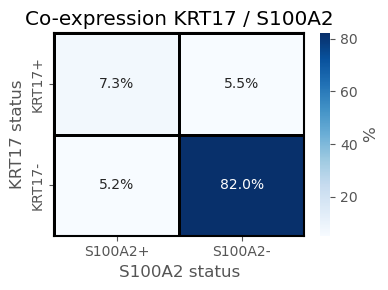

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

table = pd.crosstab(
    adata_comp.obs["KRT17_status"],
    adata_comp.obs["S100A2_status"],
    normalize="all"
) * 100

# Ajouter le symbole %
annot = table.applymap(lambda x: f"{x:.1f}%")

plt.figure(figsize=(4,3))
ax = sns.heatmap(
    table,
    annot=annot,
    fmt="",                 # Important : les annotations sont déjà des chaînes
    cmap="Blues",
    linewidths=0.75,
    linecolor="black",
    cbar_kws={"label": "%"}
)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color("black")

plt.xlabel("S100A2 status")
plt.ylabel("KRT17 status")
plt.title("Co-expression KRT17 / S100A2")
plt.tight_layout()
plt.savefig("./OUTPUT_arcsinh/cell_states/status_comparaison/KRT17_S100A2_tumour_coexpression_heatmap.png")
plt.show()

In [24]:
from pathlib import Path

In [25]:
save_dir = Path("./OUTPUT_arcsinh/cell_states/status_comparaison")

Filtering Tumour
85692 cells retained


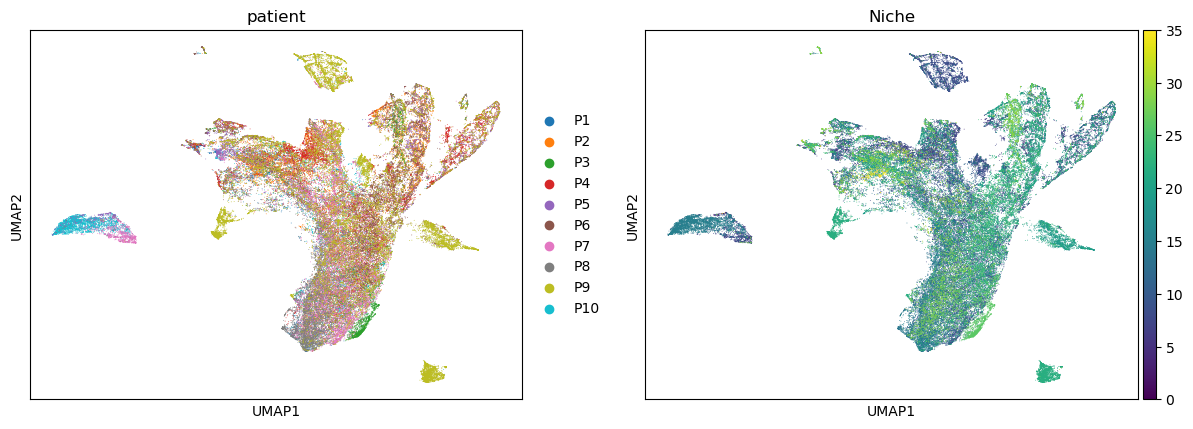

In [38]:
adata_c = run_celltype_umap(
    adata_comp,
    cell_column="Phenotype_big",
    cell_type="Tumour",
    n_hvg=None, # highly variable genes
    target_sum=None, # façon de normaliser les données de transcripto,
    n_comps = None,# nombre de pc produits par PCA
    n_pcs=None, #utilisés dans neighbors donc avant umap donc regarder variance expliquée pour aider à choisir nombre pcs
    n_neighbors=20,# utilisé pour umap
    color_by=[
        #"KRT17_status",
        "patient",
        "Niche",
        #"Phenotype",
        #"S100A2_status"
        ],
    random_state=42,
    save_dir_plot=save_dir,
    scale=False,
    normalization = None,
    t_SNE = False,
    params_dir = save_dir,
    imc = True
)

In [28]:
condition = {
    ("KRT17+", "S100A2+"): "Double positive",
    ("KRT17+", "S100A2-"): "KRT17+ S100A2-",
    ("KRT17-", "S100A2+"): "KRT17- S100A2+",
    ("KRT17-", "S100A2-"): "Double negative",
}

adata_comp.obs["double_status"].replace(mapping)

cell_id
P10_S1_28      Double positive
P10_S1_40       KRT17- S100A2+
P10_S1_48      Double positive
P10_S1_66      Double positive
P10_S1_75      Double positive
                    ...       
P9_S5_15065    Double negative
P9_S5_15067    Double negative
P9_S5_15068    Double negative
P9_S5_15071    Double negative
P9_S5_15078    Double negative
Name: double_status, Length: 85692, dtype: object

In [32]:
import matplotlib.pyplot as plt

plt.style.use("default")

     double_status  n_cells
0  Double negative    70308
1   KRT17+ S100A2-     4683
2   KRT17- S100A2+     4464
3  Double positive     6237


/tmp/ipykernel_10148/1873607003.py:108: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("double_status")["S100A2_expr"]
/tmp/ipykernel_10148/1873607003.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("double_status")["KRT17_expr"]
/tmp/ipykernel_10148/1873607003.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


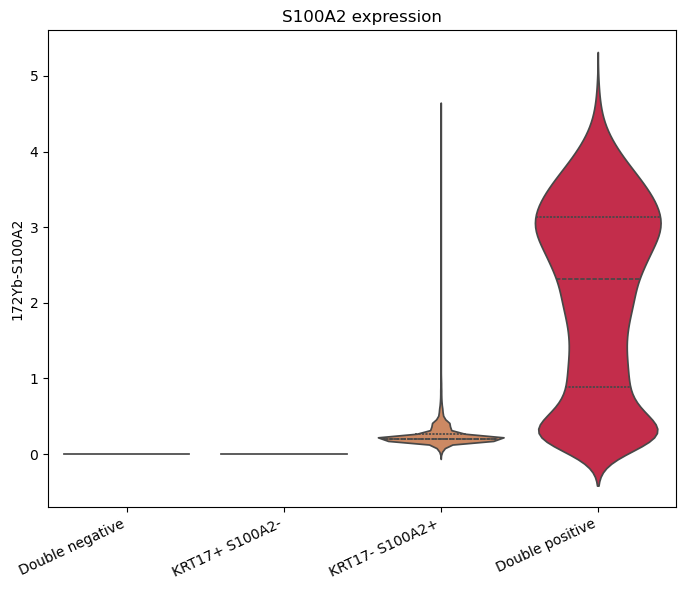

/tmp/ipykernel_10148/1873607003.py:163: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


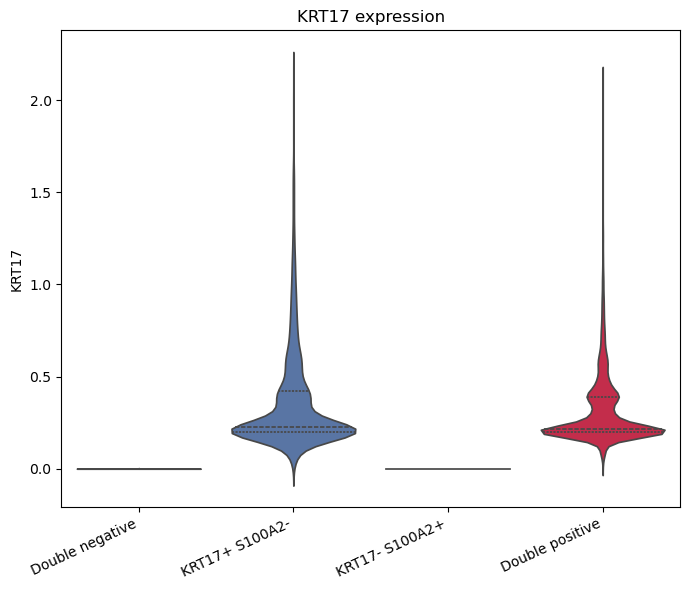

/home/mohamed.tahounza/miniconda3/envs/mosna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:961: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


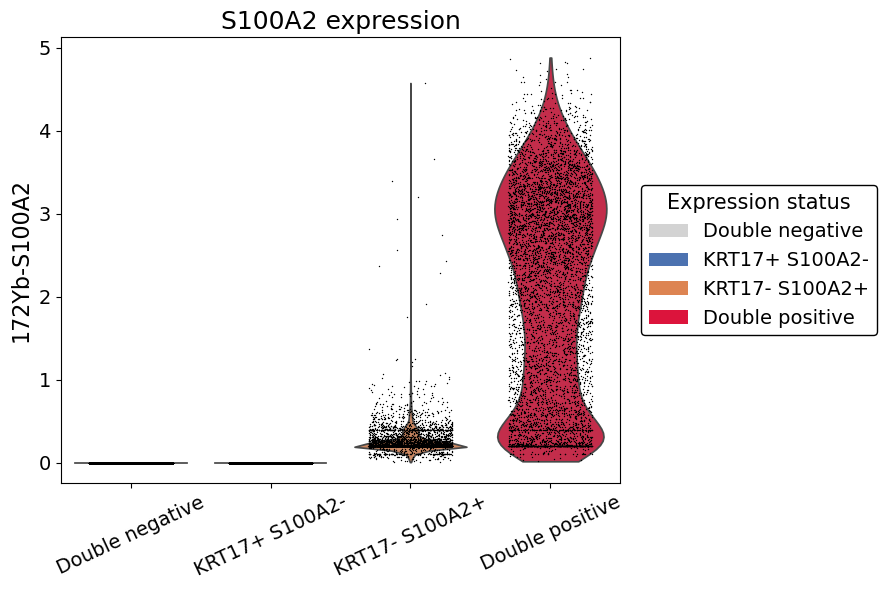

/home/mohamed.tahounza/miniconda3/envs/mosna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:961: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


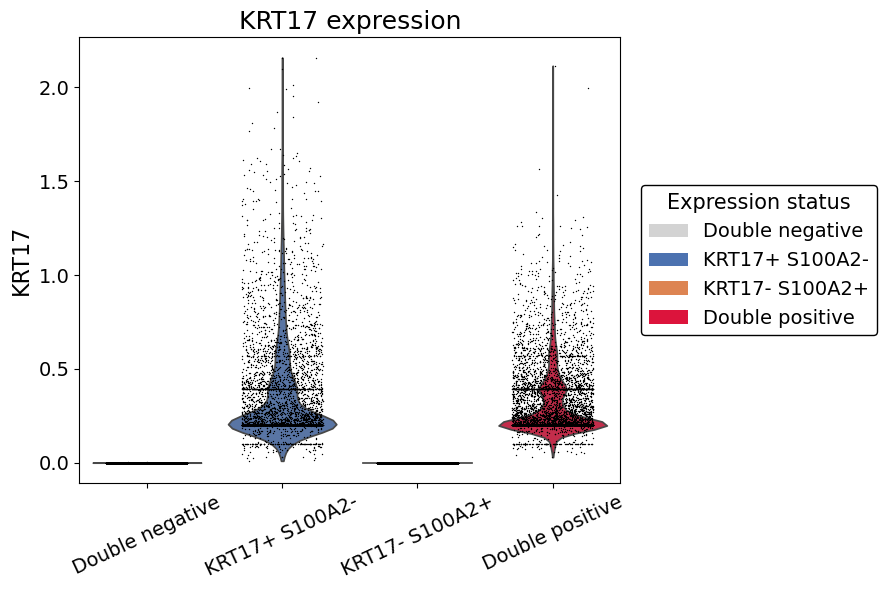


Cell counts
     double_status  n_cells
0  Double negative    70308
1   KRT17+ S100A2-     4683
2   KRT17- S100A2+     4464
3  Double positive     6237

S100A2 statistics
                   count      mean       std       min        1%        5%  \
double_status                                                                
Double negative  70308.0  0.000000  0.000000  0.000000  0.000000  0.000000   
KRT17+ S100A2-    4683.0  0.000000  0.000000  0.000000  0.000000  0.000000   
KRT17- S100A2+    4464.0  0.260772  0.187768  0.006800  0.077125  0.147707   
Double positive   6237.0  2.095675  1.242020  0.016599  0.191472  0.198690   

                      10%       25%       50%       75%       90%       95%  \
double_status                                                                 
Double negative  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
KRT17+ S100A2-   0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
KRT17- S100A2+   0.198690  0.198690  0.1986

In [37]:
import os
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ==========================================================
# Données
# ==========================================================

adata = adata_comp.copy()
import numpy as np

adata = adata_comp.copy()

# Expression S100A2
adata.obs["S100A2_expr"] = np.asarray(
    adata[:, "172Yb-S100A2"].X
).flatten()

# Expression KRT17
adata.obs["KRT17_expr"] = np.asarray(
    adata[:, "164Dy-KRT17"].X
).flatten()


# Ordre des groupes
order = [
    "Double negative",
    "KRT17+ S100A2-",
    "KRT17- S100A2+",
    "Double positive"
]

adata.obs["double_status"] = pd.Categorical(
    adata.obs["double_status"],
    categories=order,
    ordered=True
)

palette = {
    "Double negative": "lightgrey",
    "KRT17+ S100A2-": "#4C72B0",
    "KRT17- S100A2+": "#DD8452",
    "Double positive": "crimson"
}

# ==========================================================
# Dossier de sortie
# ==========================================================

output_dir = "OUTPUT_arcsinh/cell_states/double_status/"
os.makedirs(output_dir, exist_ok=True)

# ==========================================================
# Export des cellules
# ==========================================================

cols = [
    "Phenotype",
    "Phenotype_big",
    "KRT17_status",
    "S100A2_status",
    "double_status",
]

adata.obs[cols].to_csv(
    os.path.join(output_dir, "Cells_double_status.csv")
)

# ==========================================================
# Nombre de cellules
# ==========================================================

cell_counts = (
    adata.obs["double_status"]
    .value_counts(sort=False)
    .rename_axis("double_status")
    .reset_index(name="n_cells")
)

cell_counts.to_csv(
    os.path.join(output_dir, "Cell_counts.csv"),
    index=False
)

print(cell_counts)

# ==========================================================
# Statistiques descriptives
# ==========================================================

percentiles = [
    0.01,
    0.05,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
]

S100A2_stats = (
    adata.obs
    .groupby("double_status")["S100A2_expr"]
    .describe(percentiles=percentiles)
)

S100A2_stats.to_csv(
    os.path.join(output_dir, "S100A2_describe.csv")
)

KRT17_stats = (
    adata.obs
    .groupby("double_status")["KRT17_expr"]
    .describe(percentiles=percentiles)
)

KRT17_stats.to_csv(
    os.path.join(output_dir, "KRT17_describe.csv")
)

# ==========================================================
# Violin plot Seaborn : S100A2
# ==========================================================

plt.figure(figsize=(7,6))

sns.violinplot(
    data=adata.obs,
    x="double_status",
    y="S100A2_expr",
    order=order,
    palette=palette,
    inner="quart",
    density_norm="width"
)

plt.xticks(rotation=25, ha="right")
plt.xlabel("")
plt.ylabel("172Yb-S100A2")
plt.title("S100A2 expression")

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "Violin_S100A2.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================================
# Violin plot Seaborn : KRT17
# ==========================================================

plt.figure(figsize=(7,6))

sns.violinplot(
    data=adata.obs,
    x="double_status",
    y="KRT17_expr",
    order=order,
    palette=palette,
    inner="quart",
    density_norm="width"
)

plt.xticks(rotation=25, ha="right")
plt.xlabel("")
plt.ylabel("KRT17")
plt.title("KRT17 expression")

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "Violin_KRT17.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==========================================================
# Violin Scanpy : S100A2
# ==========================================================

fig, ax = plt.subplots(figsize=(9,6))

sc.pl.violin(
    adata,
    keys="172Yb-S100A2",
    groupby="double_status",
    palette=palette,
    stripplot=True,
    jitter=0.3,
    show=False,
    ax=ax
)

ax.set_title("S100A2 expression", fontsize=18)
ax.set_xlabel("")
ax.set_ylabel("172Yb-S100A2", fontsize=16)

ax.tick_params(axis="x", labelsize=14, rotation=25)
ax.tick_params(axis="y", labelsize=14)

legend = [
    Patch(facecolor=palette[x], label=x)
    for x in order
]

ax.legend(
    handles=legend,
    title="Expression status",
    title_fontsize=15,
    fontsize=14,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,          # Affiche le cadre
    edgecolor="black",     # Couleur du contour
    facecolor="white",     # Fond de la légende
    framealpha=1           # Opacité du fond
)

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "Scanpy_Violin_S100A2.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    os.path.join(save_dir, "Scanpy_Violin_S100A2.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
# ==========================================================
# Violin Scanpy : KRT17
# ==========================================================

fig, ax = plt.subplots(figsize=(9,6))

sc.pl.violin(
    adata,
    keys="KRT17_expr",
    groupby="double_status",
    palette=palette,
    stripplot=True,
    jitter=0.3,
    show=False,
    ax=ax
)

ax.set_title("KRT17 expression", fontsize=18)
ax.set_xlabel("")
ax.set_ylabel("KRT17", fontsize=16)

ax.tick_params(axis="x", labelsize=14, rotation=25)
ax.tick_params(axis="y", labelsize=14)

legend = [
    Patch(facecolor=palette[x], label=x)
    for x in order
]

ax.legend(
    handles=legend,
    title="Expression status",
    title_fontsize=15,
    fontsize=14,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,          # Affiche le cadre
    edgecolor="black",     # Couleur du contour
    facecolor="white",     # Fond de la légende
    framealpha=1           # Opacité du fond
)

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "Scanpy_Violin_KRT17.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    os.path.join(save_dir, "Scanpy_Violin_KRT17.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ==========================================================
# Résumé
# ==========================================================

print("\n========================")
print("Cell counts")
print("========================")
print(cell_counts)

print("\n========================")
print("S100A2 statistics")
print("========================")
print(S100A2_stats)

print("\n========================")
print("KRT17 statistics")
print("========================")
print(KRT17_stats)

print("\nResults saved in:")
print(output_dir)